In [1]:
import pandas as pd
import numpy as np
import os
import math
import warnings
import pickle
import hashlib
from collections import Counter
from itertools import islice

import scipy
from scipy import stats
from scipy.stats import linregress, pearsonr, percentileofscore

import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from tqdm.notebook import tqdm
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn import metrics
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import check_random_state, resample

from skopt import BayesSearchCV
from skopt.space import Real, Integer

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
from scipy.stats import percentileofscore
from sklearn.utils import check_random_state
from itertools import islice

def permtest(x, y, statistic="mean", max_samples=5000, random_state=42):
  """
  Conducts a permutation test between two independent samples.
  Parameters
  ----------
  x : ndarray
    First set of datapoints.
  y : ndarray
    Second set of datapoints.
  statistic : str or callable, optional
    Function that takes in samples x and y and reports
    statistic of interest. By default, "mean" reports
    the difference of sample means. List of default
    options are ("mean", "median").
  max_samples : int, optional.
    Maximum number of label permutations to try.
  random_state : np.random.RandomState, int, or None.
    If specified, used to seed the random number generator to shuffle the ordering of the datapoints.
  """

  # Initialize random state and function of interest
  rs = check_random_state(random_state)
  stat_func = _get_stat_func(statistic)

  # Concatenate samples
  xy = np.concatenate((x, y))
  n_x = x.size

  # Observed statistic
  observed_stat = stat_func(x, y)

  # Set the number of permutations to compute
  n_perms = max(max_samples, 100000) # Limit the number of permutations to a manageable number (e.g., 10000)

  # Allocate space for computed statistics
  shuffled_stats = np.empty(n_perms)

  # Print coverage
  print(f"Computing permutations...")

  # Sampling random permutations
  for i in range(n_perms):
    rs.shuffle(xy)
    x_ = xy[:n_x]
    y_ = xy[n_x:]
    shuffled_stats[i] = stat_func(x_, y_)

  # Compute a two-sided p-value. We take the smallest
  # percentile and then multiply by two.
  pval = 2 * min(
    percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100,
    1 - percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100
  )

  return pval

def _get_stat_func(name_or_func):
  """
  Instantiates functions that compute default statistics of interest.
  """
  # If specified function is callable
  if not isinstance(name_or_func, str):
    if callable(name_or_func):
      return name_or_func
    else:
      raise ValueError(
        "`statistic` should be a string like ('mean', 'median')"
        " or a function that takes in samples x, y and returns"
        " the statistic of interest."
      )

  # Default functions
  if name_or_func == "mean":
    return lambda x, y: np.mean(x) - np.mean(y)
  elif name_or_func == "median":
    return lambda x, y: np.median(x) - np.median(y)
  else:
    raise ValueError("Did not recognize statistic.")

In [3]:
import numpy as np

# Define the pooled function to calculate the combined value of a specific measure
def pooled(x, y, func):
  nx = len(x)
  ny = len(y)
  return np.sqrt(((nx - 1) * func(x) ** 2 + (ny - 1) * func(y) ** 2) / (nx + ny - 2))

# Define the median, using the median of quantiles
def hdmedian(x):
  return np.median(x)

# Define the hdmad function to calculate the adjusted MAD (Median Absolute Deviation)
def hdmad(x):
  return 1.4826 * hdmedian(np.abs(x - hdmedian(x)))

# Calculate the pooled MAD between two datasets x and y
def phdmad(x, y):
  return pooled(x, y, hdmad)

# Define the gamma_effect_size function to calculate the gamma effect size
def gamma_effect_size(x, y, prob):
  hdquantile_x = np.percentile(x, prob * 100)
  hdquantile_y = np.percentile(y, prob * 100)
  return (hdquantile_y - hdquantile_x) / phdmad(x, y)

# Usage example
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 4, 5, 6, 7])

# Calculate the gamma effect size
prob = 0.5 # median
gamma_effect = gamma_effect_size(x, y, prob)
print(f'Gamma effect size: {gamma_effect}')

In [4]:
def remove_outliers_iqr(data):
  """
  Removes outliers from an array based on the IQR criterion.
  
  Parameters:
  - data: NumPy array (or list).
  
  Returns:
  - NumPy array without outliers.
  """
  # Convert to a NumPy array if it is not already
  data = np.array(data)

  # Calculate Q1, Q3 and IQR
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1

  # Define lower and upper bounds
  ir_mult = 1.5
  lower_bound = Q1 - ir_mult * IQR
  upper_bound = Q3 + ir_mult * IQR

  # Filter data within bounds
  filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
  
  return filtered_data

def remove_outliers_iqr_05(data):
  """
  Removes outliers from an array based on the IQR criterion.
  
  Parameters:
  - data: NumPy array (or list).
  
  Returns:
  - NumPy array without outliers.
  """
  # Convert to a NumPy array if it is not already
  data = np.array(data)

  # Calculate Q1, Q3 and IQR
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1

  # Define lower and upper bounds
  ir_mult = 0.5
  lower_bound = Q1 - ir_mult * IQR
  upper_bound = Q3 + ir_mult * IQR

  # Filter data within bounds
  filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
  
  return filtered_data

def remove_outliers_iqr_10(data):
  """
  Removes outliers from an array based on the IQR criterion.
  
  Parameters:
  - data: NumPy array (or list).
  
  Returns:
  - NumPy array without outliers.
  """
  # Convert to a NumPy array if it is not already
  data = np.array(data)

  # Calculate Q1, Q3 and IQR
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1

  # Define lower and upper bounds
  ir_mult = 1.0
  lower_bound = Q1 - ir_mult * IQR
  upper_bound = Q3 + ir_mult * IQR

  # Filter data within bounds
  filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
  
  return filtered_data

def cliff_delta(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1_ = remove_outliers_iqr(group1)
  group2_ = remove_outliers_iqr(group2)
  
  sub_sample_size = np.min([int(group1_.shape[0]*0.7), int(group2_.shape[0]*0.7)])

  delta_l = []
  for i in range(10):
    
    group1 = resample(group1_, n_samples=sub_sample_size, replace=False, random_state=i)
    group2 = resample(group2_, n_samples=sub_sample_size, replace=False, random_state=i)
  
    # Expand both matrices to compare each value with all other values
    group1_exp = group1[:, np.newaxis] # Expands group1 to a column matrix
    group2_exp = group2[np.newaxis, :]  # Expands group2 to a row matrix
  
    # Vectorized comparisons
    greater = np.sum(group1_exp > group2_exp)
    less = np.sum(group1_exp < group2_exp)
  
    # Calculate Cliff's Delta
    n1, n2 = len(group1), len(group2)
    delta = (greater - less) / (n1 * n2)

  delta_l.append(delta)

  print('N', n1+n2, n1, n2)

  return (np.round(np.mean(delta_l), 4), np.round(np.std(delta_l)*2.58,100))

def cliff_delta05(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1_ = remove_outliers_iqr_05(group1)
  group2_ = remove_outliers_iqr_05(group2)
  
  sub_sample_size = np.min([int(group1_.shape[0]*0.7), int(group2_.shape[0]*0.7)])

  delta_l = []
  for i in range(10):
    
    group1 = resample(group1_, n_samples=sub_sample_size, replace=False, random_state=i)
    group2 = resample(group2_, n_samples=sub_sample_size, replace=False, random_state=i)
  
    # Expand both matrices to compare each value with all other values
    group1_exp = group1[:, np.newaxis] # Expands group1 to a column matrix
    group2_exp = group2[np.newaxis, :]  # Expands group2 to a row matrix
  
    # Vectorized comparisons
    greater = np.sum(group1_exp > group2_exp)
    less = np.sum(group1_exp < group2_exp)
  
    # Calculate Cliff's Delta
    n1, n2 = len(group1), len(group2)
    delta = (greater - less) / (n1 * n2)

  delta_l.append(delta)

  print('N', n1+n2, n1, n2)

  return (np.round(np.mean(delta_l), 4), np.round(np.std(delta_l)*2.58,100))

def cliff_delta10(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1_ = remove_outliers_iqr_10(group1)
  group2_ = remove_outliers_iqr_10(group2)
  
  sub_sample_size = np.min([int(group1_.shape[0]*0.7), int(group2_.shape[0]*0.7)])

  delta_l = []
  for i in range(10):
    
    group1 = resample(group1_, n_samples=sub_sample_size, replace=False, random_state=i)
    group2 = resample(group2_, n_samples=sub_sample_size, replace=False, random_state=i)
  
    # Expand both matrices to compare each value with all other values
    group1_exp = group1[:, np.newaxis] # Expands group1 to a column matrix
    group2_exp = group2[np.newaxis, :]  # Expands group2 to a row matrix
  
    # Vectorized comparisons
    greater = np.sum(group1_exp > group2_exp)
    less = np.sum(group1_exp < group2_exp)
  
    # Calculate Cliff's Delta
    n1, n2 = len(group1), len(group2)
    delta = (greater - less) / (n1 * n2)

  delta_l.append(delta)

  print('N', n1+n2, n1, n2)

  return (np.round(np.mean(delta_l), 4), np.round(np.std(delta_l)*2.58,100))


def calculate_z_from_u(group1, group2, u_statistic):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1 = remove_outliers_iqr(group1)
  group2 = remove_outliers_iqr(group2)

  # Group sizes
  n1, n2 = len(group1), len(group2)

  # Calculate the mean and standard deviation of U
  mu_u = (n1 * n2) / 2
  sigma_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)

  # Calculate the Z value
  z_value = (u_statistic - mu_u) / sigma_u

  r_value = z_value / np.sqrt(n1 + n2)

  return r_value


def rank_biserial_from_u(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1 = remove_outliers_iqr_01(group1)
  group2 = remove_outliers_iqr_01(group2)

  # Calculate the U statistic using the Mann-Whitney U test
  u_statistic, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')

  # Group sizes
  n1, n2 = len(group1), len(group2)

  # Calculate the Rank-Biserial Correlation based on the formula 1 - (2 * U) / (n1 * n2)
  r_biserial = 1 - (2 * u_statistic) / (n1 * n2)

  return r_biserial

def rank_biserial_from_u10(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1 = remove_outliers_iqr_10(group1)
  group2 = remove_outliers_iqr_10(group2)

  # Calculate the U statistic using the Mann-Whitney U test
  u_statistic, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')

  # Group sizes
  n1, n2 = len(group1), len(group2)

  # Calculate the Rank-Biserial Correlation based on the formula 1 - (2 * U) / (n1 * n2)
  r_biserial = 1 - (2 * u_statistic) / (n1 * n2)

  return r_biserial

In [5]:
def _get_table_labels(table):
  """
  Returns classic a, b, c, d labels for contingency table calcs.
  """
  a = table[0][0]
  b = table[0][1]
  c = table[1][0]
  d = table[1][1]

  return a, b, c, d


def _ordered_table(table):
  """
  Determine type of table input. Find classic a, b, c, d labels
  for contigency table calculations.
  """
  if type(table) is list:
    a, b, c, d = _get_table_labels(table)
  elif type(table) is pd.core.frame.DataFrame:
    a, b, c, d = _get_table_labels(table.values)
  elif type(table) is np.ndarray:
    a, b, c, d = _get_table_labels(table)
  else:
    raise TypeError('table format not recognized')

  return a, b, c, d


def _conf_interval(ratio, std_error):
  """
  Calculate 95% confidence interval for odds ratio and relative risk.
  """

  _lci = np.log(ratio) - 1.96*std_error
  _uci = np.log(ratio) + 1.96*std_error

  lci = round(np.exp(_lci), 2)
  uci = round(np.exp(_uci), 2)

  return (lci, uci)

def _numeric_summary(column):
  """
  Finds count, number of missing values, min, median, mean, std, and
  max.
  See summary()
  """
  names = ['count', 'missing', 'min', 'median', 'mean', 'std', 'max']
  _count = len(column)
  _miss = _count - len(column.dropna())
  _min = column.min()
  _median = column.median()
  _mean = column.mean()
  _std = column.std()
  _max = column.max()
  summ = pd.Series([_count, _miss, _min, _median, _mean, _std, _max], index=names)

  return summ


def _categorical_summary(column, n=None):
  """
  Finds count and frequency of each unique value in the column.
  See summary().
  """
  if n is not None:
    _count = column.value_counts()[:n]
  else:
    _count = column.value_counts()
  names = ['count', 'freq']
  _freq = column.value_counts(normalize=True)[:n]
  summ = pd.DataFrame([_count, _freq], index=names).T

  return summ


def _summary_calc(column, by=None):
  """
  Calculates approporiate summary statistics based on data type.
  PARAMETERS
  ----------------------
  column = one column (series) of pandas df
  by = optional. stratifies summary statistics by each value in the
        column.
  RETURNS
  ----------------------
  if column data type is numeric, returns summary statistics
  if column data type is an object, returns count and frequency of
    top 5 most common values
  """
  if column.dtype == 'float64' or column.dtype == 'int64':
    coltype = 'numeric'
  elif column.dtype == 'object':
    coltype = 'object'


  if by is None:
    if coltype == 'numeric':
      summ = _numeric_summary(column)

    elif coltype == 'object':
      summ = _categorical_summary(column, 5)

  else:

    if coltype == 'numeric':
      column_list = []

      vals = by.dropna().unique()
      for value in vals:
        subcol = column[by == value]
        summcol = _numeric_summary(subcol)
        column_list.append(summcol)

      summ = pd.DataFrame(column_list, index=vals)

    elif coltype == 'object':
      subcol = column.groupby(by)
      summ = _categorical_summary(subcol)
      #summ = _summ.sort_values(by=subcol)

  return summ


def reproduction_number(G, index_cases=True, plot=True):
  """
  Finds each case's basic reproduction number, which is the number of secondary
  infections each case produces.
  PARAMETERS
  ----------------
  G = networkx object
  index_cases = include index nodes, i.e. those at generation 0. Default is True.
         Excluding them is useful if you want to calculate the human to human
         reproduction number without considering zoonotically acquired cases.
  summary = print summary statistics of the case reproduction numbers
  plot = create histogram of case reproduction number distribution.
  RETURNS
  ----------------
  pandas series of case reproduction numbers and matplotlib figure
  and axis objects if plot=True
  """

  if index_cases == True:
    R = pd.Series(G.out_degree())

  elif index_cases == False:
    degrees = {}

    for n in G.node:
      if G.node[n]['generation'] > 0:
        degrees[n] = G.out_degree(n)
    R = pd.Series(degrees)

  print('Summary of reproduction numbers')
  print(R.describe(), '\n')

  if plot == True:
    fig, ax = plt.subplots()
    R.hist(ax=ax, alpha=.5)
    ax.set_xlabel('Secondary cases')
    ax.set_ylabel('Count')
    ax.grid(False)
    return R, fig, ax

  else:
    return R


def generation_analysis(G, attribute, plot=True):
  """
  Analyzes an attribute, e.g. health status, by generation.
  PARAMETERS
  -------------
  G = networkx object
  attribute = case attribute for analysis, e.g. health status or sex
  table = print cross table of attribute by generation. Default is true.
  plot = produce histogram of attribute by generation. Default is true.
  RETURNS
  --------------
  matplotlib figure and axis objects
  """

  gen_df = pd.DataFrame(G.node).T

  print('{} by generation').format(attribute)
  table = pd.crosstab(gen_df.generation, gen_df[attribute], margins=True)
  print(table, '\n')

  if plot == True:
    fig, ax = plt.subplots()
    ax.set_aspect('auto')
    pd.crosstab(gen_df.generation, gen_df[attribute]).plot(kind='bar', ax=ax, alpha=.5, rot=0)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Case count')
    ax.grid(False)
    ax.legend(loc='best');
    return fig, ax, table
  else:
    return table


def create_2x2(df, row, column, row_order, col_order):
  """
  2x2 table of disease and exposure in traditional epi order.
  Table format:
        Disease
  Exposure  YES   NO
  YES     a    b
  NO     c    d
  PARAMETERS
  -----------------------
  df = pandas dataframe of line listing
  row = name of exposure row as string
  column = name of outcome column as string
  row_order = list of length 2 of row values in yes/no order.
        Example: ['Exposed', 'Unexposed']
  col_order = list of length 2 column values in yes/no order.
        Example: ['Sick', 'Not sick']
  RETURNS
  ------------------------
  pandas dataframe of 2x2 table. Prints odds ratio and relative risk.
  """
  if type(col_order) != list or type(row_order) != list:
    raise TypeError('row_order and col_order must each be lists of length 2')

  if len(col_order) != 2 or len(row_order) != 2:
    raise AssertionError('row_order and col_order must each be lists of length 2')

  _table = pd.crosstab(df[row], df[column], margins=True).to_dict()

  trow = row_order[0]
  brow = row_order[1]
  tcol = col_order[0]
  bcol = col_order[1]

  table = pd.DataFrame(_table, index=[trow, brow, 'All'], columns=[tcol, bcol, 'All'])

  return table


def analyze_2x2(table):
  """
  Prints odds ratio, relative risk, and chi square.
  See also create_2x2(), odds_ratio(), relative_risk(), and chi2()
  PARAMETERS
  --------------------
  2x2 table as pandas dataframe, numpy array, or list in format [a, b, c, d]
  Table format:
        Disease
  Exposure  YES   NO
  YES     a    b
  NO     c    d
  """

  odds_ratio(table)
  relative_risk(table)
  attributable_risk(table)
  chi2(table)


def odds_ratio(table):
  """
  Calculates the odds ratio and 95% confidence interval. See also
  analyze_2x2()
  *Cells in the table with a value of 0 will be replaced with .1
  PARAMETERS
  ----------------------
  table = accepts pandas dataframe, numpy array, or list in [a, b, c, d] format.
  RETURNS
  ----------------------
  returns and prints odds ratio and tuple of 95% confidence interval
  """
  
  a, b, c, d = _ordered_table(table)

  ratio = (a*d)/(b*c)
  or_se = np.sqrt((1/a)+(1/b)+(1/c)+(1/d))
  or_ci = _conf_interval(ratio, or_se)
  print('Odds ratio: {} (95% CI: {})'.format(round(ratio, 2), or_ci))

  return round(ratio, 2), or_ci




def relative_risk(table, display=True):
  """
  Calculates the relative risk and 95% confidence interval. See also
  analyze_2x2().
  *Cells in the table with a value of 0 will be replaced with .1
  PARAMETERS
  ----------------------
  table = accepts pandas dataframe, numpy array, or list in [a, b, c, d] format.
  RETURNS
  ----------------------
  returns and prints relative risk and tuple of 95% confidence interval
  """
  
  a, b, c, d = _ordered_table(table)

  rr = (a/(a+b))/(c/(c+d))
  rr_se = np.sqrt(((1/a)+(1/c)) - ((1/(a+b)) + (1/(c+d))))
  rr_ci = _conf_interval(rr, rr_se)

  if display is not False:
    print('Relative risk: {} (95% CI: {}-{})\n'.format(round(rr, 2), round(rr_ci[0],2), round(rr_ci[1], 2)))

  return rr, rr_ci


def attributable_risk(table):
  """
  Calculate the attributable risk, attributable risk percent,
  and population attributable risk.
  PARAMETERS
  ----------------
  table = 2x2 table. See 2x2_table()
  RETURNS
  ----------------
  prints and returns attributable risk (AR), attributable risk percent
  (ARP), population attributable risk (PAR) and population attributable
  risk percent (PARP).
  """
  a, b, c, d = _ordered_table(table)
  N = a + b + c + d

  ar = (a/(a+b))-(c/(c+d))
  ar_se = np.sqrt(((a+c)/N)*(1-((a+c)/N))*((1/(a+b))+(1/(c+d))))
  ar_ci = (round(ar-(1.96*ar_se), 2), round(ar+(1.96*ar_se), 2))

  rr, rci = relative_risk(table, display=False)
  arp = 100*((rr-1)/(rr))
  arp_se = (1.96*ar_se)/ar
  arp_ci = (round(arp-arp_se, 2), round(arp+arp_se, 3))

  par = ((a+c)/N) - (c/(c+d))
  parp = 100*(par/(((a+c)/N)))

  print('Attributable risk: {} (95% CI: {})'.format(round(ar, 3), ar_ci))
  print('Attributable risk percent: {}% (95% CI: {})'.format(round(arp, 2), arp_ci))
  print('Population attributable risk: {}'.format(round(par, 3)))
  print('Population attributable risk percent: {}% \n'.format(round(parp, 2)))

  return ar, arp, par, parp


def my_attributable_risk(table, print_result = True):
  """
  Calculate the attributable risk, attributable risk percent,
  and population attributable risk.
  PARAMETERS
  ----------------
  table = 2x2 table. See 2x2_table()
  RETURNS
  ----------------
  prints and returns attributable risk (AR), attributable risk percent
  (ARP), population attributable risk (PAR) and population attributable
  risk percent (PARP).
  """
  a, b, c, d = _ordered_table(table)
  N = a + b + c + d

  ar = (a/(a+b))-(c/(c+d))
  ar_se = np.sqrt(((a+c)/N)*(1-((a+c)/N))*((1/(a+b))+(1/(c+d))))
  ar_ci = (round(ar-(1.96*ar_se), 2), round(ar+(1.96*ar_se), 2))

  rr, rci = relative_risk(table, display=False)
  arp = 100*((rr-1)/(rr))
  arp_se = (1.96*ar_se)/ar
  arp_ci = (round(arp-arp_se, 2), round(arp+arp_se, 3))

  par = ((a+c)/N) - (c/(c+d))
  parp = 100*(par/(((a+c)/N)))

  if(print_result):
    print('Attributable risk: {} (95% CI: {})'.format(round(ar, 3), ar_ci))
    print('Attributable risk percent: {}% (95% CI: {})'.format(round(arp, 2), arp_ci))
    print('Population attributable risk: {}'.format(round(par, 3)))
    print('Population attributable risk percent: {}% \n'.format(round(parp, 2)))

  return arp, arp_ci

def chi2(table):
  """
  Scipy.stats function to calculate chi square.
  PARAMETERS
  ----------------------
  table = accepts pandas dataframe or numpy array. See also
  analyze_2x2().
  RETURNS
  ----------------------
  returns chi square with yates correction, p value,
  degrees of freedom, and array of expected values.
  prints chi square and p value
  """
  chi2, p, dof, expected = chi2_contingency(table)
  #print('Chi square: {}'.format(chi2))
  #print('p value: {}'.format(p))

  return chi2, p, dof, expected


def summary(data, by=None):
  """
  Displays approporiate summary statistics for each column in a line listing.
  PARAMETERS
  ----------------------
  data = pandas data frame or series
  RETURNS
  ----------------------
  for each column in the dataframe, or for hte series:
  - if column data type is numeric, returns summary statistics
  - if column data type is non-numeric, returns count and frequency of
    top 5 most common values.
  EXAMPLE
  ----------------------
  df = pd.DataFrame({'Age' : [10, 12, 14], 'Group' : ['A', 'B', 'B'] })
  In: summary(df.Age)
  Out:
    count    3
    missing   0
    min    10
    median   12
    mean    12
    std     2
    max    14
    dtype: float64
  In: summary(df.Group)
  Out:
      count   freq
    B   2 0.666667
    A   1 0.333333
  In:summary(df.Age, by=df.Group)
  Out   count missing min median mean   std max
    A   1    0  10   10  10    NaN  10
    B   2    0  12   13  13 1.414214  14
  """
  if type(data) == pd.core.series.Series:
    summ = _summary_calc(data, by=by)
    return summ

  elif type(data) == pd.core.frame.DataFrame:
    for column in data:
      summ = _summary_calc(data[column], by=None)
      print('----------------------------------')
      print(column, '\n')
      print(summ)


def diagnostic_accuracy(table, display=True):
  """
  Calculates the sensitivity, specificity, negative and positive predictive values
  of a 2x2 table with 95% confidence intervals. Note that confidence intervals
  are made based on a normal approximation, and may not be appropriate for
  small sample sizes.
  PARAMETERS
  ----------------------
  table = accepts pandas dataframe, numpy array, or list in [a, b, c, d] format.
  RETURNS
  ----------------------
  returns and prints diagnostic accuracy estimates and tuple of 95% confidence interval
  Author: Eric Lofgren
  """
  a, b, c, d = _ordered_table(table)

  sen = (a/(a+c))
  sen_se = np.sqrt((sen*(1-sen))/(a+c))
  sen_ci = (sen-(1.96*sen_se),sen+(1.96*sen_se))
  spec = (d/(b+d))
  spec_se = np.sqrt((spec*(1-spec))/(b+d))
  spec_ci = (spec-(1.96*spec_se),spec+(1.96*spec_se))
  PPV = (a/(a+b))
  PPV_se = np.sqrt((PPV*(1-PPV))/(a+b))
  PPV_ci = (PPV-(1.96*PPV_se),PPV+(1.96*PPV_se))
  NPV = (d/(c+d))
  NPV_se = np.sqrt((NPV*(1-NPV))/(c+d))
  NPV_ci = (NPV-(1.96*NPV_se),NPV+(1.96*NPV_se))

  if display is not False:
    print('Sensitivity: {} (95% CI: {})\n'.format(round(sen, 2), sen_ci))
    print('Specificity: {} (95% CI: {})\n'.format(round(spec, 2), spec_ci))
    print('Positive Predictive Value: {} (95% CI: {})\n'.format(round(PPV, 2), PPV_ci))
    print('Negative Predictive Value: {} (95% CI: {})\n'.format(round(NPV, 2), NPV_ci))

  return sen,sen_ci,spec,spec_ci,PPV,PPV_ci,NPV,NPV_ci


def kappa_agreement(table, display=True):
  """
  Calculated an unweighted Cohen's kappa statistic of observer agreement for a 2x2 table.
  Note that the kappa statistic can be extended to an n x m table, but this
  implementation is restricted to 2x2.
  PARAMETERS
  ----------------------
  table = accepts pandas dataframe, numpy array, or list in [a, b, c, d] format.
  RETURNS
  ----------------------
  returns and prints the Kappa statistic
  Author: Eric Lofgren
  """
  a, b, c, d = _ordered_table(table)
  n = a + b + c + d
  pr_a = ((a+d)/n)
  pr_e = (((a+b)/n) * ((a+c)/n)) + (((c+d)/n) * ((b+d)/n))
  k = (pr_a - pr_e)/(1 - pr_e)
  if display is not False:
    print("Cohen's Kappa: {}\n").format(round(k, 2))

  return k



In [6]:
def plot_coef(coef_df_all, results_labels_df_all, title = ''):

  df = coef_df_all.iloc[1::, 0:2].sort_values(by='Estimate mean', ascending=False)
  
  colors_palette = get_bar_colors(df.reset_index().rename(columns={'index':'Features'}), X_cat_)
  sns.barplot(x='Estimate mean', y=df.index, data=df, palette=colors_palette, orient='h')
  plt.xlabel('Estimate mean')
  plt.ylabel('Variable')
  #plt.title('Estimate mean con Error Bars (Estimate std)')
  plt.xlim([0, 0.55])
  
  
  r2 = np.round(coef_df_all.loc['_intercept', 'R2'],2)
  f2 = np.round(coef_df_all.loc['_intercept', 'F2'],2)
  rmse = np.round(coef_df_all.loc['_intercept', 'rmse'],2)
  mde = np.round(coef_df_all.loc['_intercept', 'MDE'],2)
  mae = np.round(coef_df_all.loc['_intercept', 'MAE'],2)
  
  y_true = results_labels_df_all['y_labels']
  y_pred = results_labels_df_all['y_pred']
  
  correlacion, p_value = pearsonr(y_true, y_pred)
  
  
  plt.text( 0.23, df.shape[0]-6, r'$R^{2}$: ' + str(np.round(r2, 2)), va='center', ha='left')
  plt.text( 0.23, df.shape[0]-5, r'$F^{2}$: ' + str(np.round(f2, 2)), va='center', ha='left')
  plt.text( 0.23, df.shape[0]-4, f'corr: {correlacion:.2f}', va='center', ha='left')
  plt.text( 0.23, df.shape[0]-3, f'RMSE: {rmse:.2f}', va='center', ha='left')
  plt.text( 0.23, df.shape[0]-2, f'MDE: {mde:.2f}', va='center', ha='left')
  plt.text( 0.23, df.shape[0]-1, f'MAE: {mae:.2f}', va='center', ha='left')

  plt.title(title)


def plot_coef_v01(coef_df_for_plot, results_labels_df_for_plot, df_directions_for_plot):

  df_directions_for_plot = df_directions_for_plot.set_index('index')
  list_coef = list(coef_df_for_plot.index)
  list_coef.remove('_intercept')
  coef_df_for_orig = coef_df_for_plot.copy()
  coef_df_for_plot['coef_sign'] = 0
  
  for i in list_coef:
    sign = df_directions_for_plot.loc[i, 'coef']
    if(sign<0):
      sign = -1
    else:
      sign = 1
  
    coef_df_for_plot.loc[i, 'coef_sign'] = coef_df_for_plot.loc[i, 'Estimate mean']*sign
  
  coef_df_for_plot['color'] = coef_df_for_plot['coef_sign'].apply(lambda x: 'red' if x > 0 else 'blue')
  
  coef_df_for_plot_sort = coef_df_for_plot.iloc[1::, :].sort_values(by='Estimate mean', ascending=False)
  coef_df_for_plot_sort = coef_df_for_plot_sort[['Estimate mean', 'Estimate std', 'coef_sign', 'color']]
  coef_df_for_plot_sort.reset_index(inplace = True)
  
  #plt.figure(figsize=(3, 4))

  if(coef_df_for_plot_sort.loc[0, 'color'] == 'blue'):
    sns.barplot(x='coef_sign', y='index', data=coef_df_for_plot_sort, hue='color', dodge=False, palette=['royalblue', 'firebrick'], orient='h' ,legend=False)
  else:
    sns.barplot(x='coef_sign', y='index', data=coef_df_for_plot_sort, hue='color', dodge=False, palette=['firebrick', 'royalblue'], orient='h' ,legend=False)
    
  plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
  plt.xlim([-0.3, 0.3])
  plt.xlabel('Features importance')
  plt.ylabel('Features')
  
  r2 = np.round(coef_df_for_orig.loc['_intercept', 'R2'],4)
  f2 = np.round(coef_df_for_orig.loc['_intercept', 'F2'],4)
  rmse = np.round(coef_df_for_orig.loc['_intercept', 'rmse'],4)
  try:
    mde = np.round(coef_df_for_orig.loc['_intercept', 'MDE'],4)
  except:
    mde = 0
  mae = np.round(coef_df_for_orig.loc['_intercept', 'MAE'],4)
  
  y_true = results_labels_df_for_plot['y_labels']
  y_pred = results_labels_df_for_plot['y_pred']
  
  correlacion, p_value = pearsonr(y_true, y_pred)
  
  plt.title(r'$R^{2}$: ' + str(np.round(r2, 4)) + r'  $F^{2}$: ' + str(np.round(f2, 4)) + f'  $r$: {correlacion:.4f}' + f'\nRMSE: {rmse:.4f}' + f'  MDE: {mde:.4f}'+ f'  MAE: {mae:.4f}');
  
  plt.text( -0.20, 7, 'Protected\nFactors', va='center', ha='center', color='blue')
  plt.text( 0.20, 7, 'Risk\nFactors', va='center', ha='center', color='red')

  return coef_df_for_plot_sort

In [7]:
def mean_directional_accuracy(y_true, y_pred):
  
  differences = np.array(y_pred) - np.array(y_true) 
  signs = np.sign(differences)
  mde = np.mean(signs)
  return mde

def mean_absolute_error(y_true, y_pred):

  y_true = np.array(y_true)
  y_pred = np.array(y_pred)
  absolute_errors = np.abs(y_pred - y_true)
  mae = np.mean(absolute_errors)
  
  return mae

def coef_pval(coef_array_mean_, X_, y_, y_p):

  n = X_.shape[0]
  t = coef_tval(coef_array_mean_, X_, y_, y_p)
  p = 2 * (1 - scipy.stats.t.cdf(abs(t), n - 1))
  return p


def coef_tval(coef_array_mean_, X_, y_, y_p):
  
  '''
    coef_tval for OLS of statsmodels
  '''
  
  a = np.array(coef_array_mean_[0][0]/ coef_se(X_, y_, y_p)[0])
  b = np.array(coef_array_mean_[1::].flatten() / coef_se(X_, y_, y_p)[1:])
  return np.append(a, b)


def coef_se(X_, y_, y_p):
  
  '''
    coef_se for OLS of statsmodels
  '''
  n = X_.shape[0]
  
  X1 = np.hstack((np.ones((n, 1)), np.matrix(X_)))
  se_matrix = scipy.linalg.sqrtm(
    metrics.mean_squared_error(y_, y_p) *
    np.linalg.inv(X1.T * X1)
  )
  return np.diagonal(se_matrix)

def directional_accuracy(predicted_values, true_values):

  predicted_values = np.array(predicted_values)
  true_values = np.array(true_values)  

  difference_direction = np.sign(predicted_values - true_values)  
  correct_direction_count = np.sum(difference_direction == 1) + np.sum(difference_direction == -1)
  
  directional_accuracy_score = correct_direction_count / len(predicted_values)
  
  return directional_accuracy_score



from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.api import GLM
from statsmodels.api import families


def Regression_GBR(X, y, min_, max_, n_splits, params_b = -1, shaps_comp = False):
  
  import statsmodels.api as sm

  scaler = MinMaxScaler((0.05, 0.95))
  #scaling_data = scaler.fit_transform(X)
  #X = pd.DataFrame(scaling_data, columns= X.columns, index = X.index)

  for i in range(min_, max_):
    y_labels = []
    y_predicts = []
    #n_splits = 7

    y_pred_ = []
    y_test_ = []
    r_squared_l = []
    rmse_l = []
    mse_l = []

    results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])

    r_squared_ = 0
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=i)

    lista_vars = list(X)

    coef_array = np.zeros([len(lista_vars)+1, n_splits])
    coef_t_value = np.zeros([len(lista_vars)+1, n_splits])
    coef_p_value = np.zeros([len(lista_vars)+1, n_splits])

    iter_ = 0
    for train_index, test_index in kf.split(X):

        import warnings
        warnings.filterwarnings("ignore")

        print(f"Fold: {iter_}")
      
        X_train, X_test = X.iloc[train_index, :], X.iloc[test_index,:]
        y_train, y_test = y[train_index], y[test_index]

        scaling_data = scaler.fit_transform(X_train)
        X_train = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)

        scaling_data = scaler.transform(X_test)
        X_test = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)

        if(params_b == -1):
          model = GradientBoostingRegressor(random_state=42)
        else:
          model = GradientBoostingRegressor(random_state=42, **params_b)
          


        model.fit(X_train, y_train)


        coef_array[0,iter_] = np.nan
        coef_array[1::,iter_] = np.array(model.feature_importances_)

        predicted_values = model.predict(X_test)


        mse = np.mean((y_test - predicted_values)**2)

        rmse = np.sqrt(mse)

        y_labels.extend(list(y_test))
        y_predicts.extend(list(predicted_values))

        #r_squared_ += results.rsquared


        y_pred_.extend(list(predicted_values))
        y_test_.extend(y_test)
        
         #- No Adjust gap------------------------
        gap_test = predicted_values - y_test
         #- No Adjust gap------------------------
          
        
        #- Adjust gap------------------------  

        #gap_train = model.predict(X_train) - y_train
        #model_gap = GLM(gap_train, y_train, family=families.Gaussian())
        #results_gap = model_gap.fit()
        #corrected_gap = gap_test - results_gap.predict(gap_test)

        gap_train = model.predict(X_train) - y_train


        slope, intercept, _, _, _ = linregress(y_train, gap_train)

        corrected_gap = gap_test - (slope * y_test + intercept)

         #- Adjust gap------------------------
         
        r_squared_l.append(r2_score(y_test, model.predict(X_test)))

        mse_l.append(np.round(mean_squared_error(y_test, model.predict(X_test)), 6))
        rmse_l.append(np.round(math.sqrt(mean_squared_error(y_test, model.predict(X_test))), 6))

        result = np.column_stack((y_test, model.predict(X_test), gap_test, corrected_gap))
        temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected'])
        temp_df['ID'] = X_test.index

        results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)

        iter_+=1

    n = len(y_predicts)
    p = X.shape[1]
    r_squared = r2_score(y_labels, y_predicts)
    
    mde = mean_directional_accuracy(y_labels, y_predicts)
    mae = mean_absolute_error(y_labels, y_predicts)
    
    k = X.shape[1] - 1
    r_squared_adj = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)

    mse = (np.round(mean_squared_error(y_labels, y_predicts), 6))
    rmse = (np.round(math.sqrt(mean_squared_error(y_labels, y_predicts)), 6))

    r_squared_ = r_squared_/n_splits
    F = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
    p_value = np.round(scipy.stats.f.sf(F, n, (n - p - 1)), 15)

    F2 =r_squared / (1 - r_squared)

    coef_array_mean = np.zeros([len(lista_vars)+1, 1])
    coef_array_std = np.zeros([len(lista_vars)+1, 1])

    for j in range(len(lista_vars)+1):
      coef_array_mean[j] = coef_array[j,:].mean()
      coef_array_std[j] = coef_array[j,:].std()

    coef_df = pd.DataFrame(
                index= ['_intercept'] + lista_vars,
                columns=['Estimate mean', 'Estimate std','t value', 'p value'])

    coef_df['Estimate mean'] = coef_array_mean
    coef_df['Estimate std'] = coef_array_std
    coef_df['t value'] = coef_tval(coef_array_mean, X, y_labels, y_predicts)
    coef_df['p value'] = coef_pval(coef_array_mean, X, y_labels, y_predicts)

    coef_df.loc['_intercept', 'R2'] = r_squared
    coef_df.loc['_intercept', 'R2 adj'] = r_squared_adj
    coef_df.loc['_intercept', 'R2 [+-]'] = 1*np.std(r_squared_l)
    coef_df.loc['_intercept', 'F2'] = F2
    coef_df.loc['_intercept', 'mse'] = mse
    coef_df.loc['_intercept', 'mse [+-]'] = 1*np.std(mse_l)
    coef_df.loc['_intercept', 'rmse'] = rmse
    coef_df.loc['_intercept', 'rmse [+-]'] = 1*np.std(rmse_l)
    coef_df.loc['_intercept', 'outcome var'] = np.var(y)
    #
    coef_df.loc['_intercept', 'F'] = F
    coef_df.loc['_intercept', 'F-p_value'] = p_value
    
    coef_df.loc['_intercept', 'MDE'] = mde
    coef_df.loc['_intercept', 'MAE'] = mae

    r_squared = r2_score(y_labels, y_predicts)
    #if(r_squared>0.1):
    #  print(i, np.round(r_squared_, 3), np.round(r_squared,3))
    
    
  results_labels_df['y_pred_corrected'] = results_labels_df['y_labels'] + results_labels_df['GAP_corrected']
  results_labels_df = results_labels_df[['ID','y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'y_pred_corrected']]
  
  if(shaps_comp):
    if(params_b == -1):
      model = GradientBoostingRegressor(random_state=42)
    else:
      model = GradientBoostingRegressor(random_state=42, **params_b)

    model.fit(X_train, y_train)
    
    explainer = shap.Explainer(model, X)
    #shap_values = explainer(X)
      
    return [coef_df, r_squared_, results_labels_df, explainer, kf.split(X)]
  else:
    return [coef_df, r_squared_, results_labels_df, kf.split(X)]
    

In [8]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import linregress
import numpy as np
import pandas as pd
import math
import warnings
from skopt import BayesSearchCV
from skopt.space import Real, Integer

def Regression_GBR_nested(X, y, outer_splits=10, inner_splits=5, shaps_comp=False):
  warnings.filterwarnings("ignore")

  scaler = MinMaxScaler((0.05, 0.95))

  outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=42)
  param_grid = {
    'n_estimators': Integer(50, 500),     # Number of trees
    'learning_rate': Real(0.01, 0.5, prior='log-uniform'), # Learning rate
    'max_depth': Integer(1, 5),        # Maximum depth of trees
    'min_samples_split': Integer(2, 10),    # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),    # Minimum samples at a leaf node
  }

  y_labels = []
  y_predicts = []
  r_squared_l = []
  mse_l = []
  rmse_l = []

  results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])

  coef_array = np.zeros([X.shape[1] + 1, outer_splits])
  lista_vars = list(X.columns)

  for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"Fold: {fold}")
    
    scaling_data = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)

    scaling_data = scaler.transform(X_test)
    X_test = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
    
    model = GradientBoostingRegressor(random_state=42)
    inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=42)
    
    bayes_search = BayesSearchCV(
      estimator=model,
      search_spaces=param_grid,
      n_iter=3,       
      scoring='r2', 
      cv=inner_cv,          
      n_jobs=-1,       
      random_state=42
    )
    bayes_search.fit(X_train, y_train)

    best_model = bayes_search.best_estimator_

    y_pred = best_model.predict(X_test)
    gap_test = y_pred - y_test
    gap_train = best_model.predict(X_train) - y_train

    slope, intercept, _, _, _ = linregress(y_train, gap_train)
    corrected_gap = gap_test - (slope * y_test + intercept)

    result = np.column_stack((y_test, y_pred, gap_test, corrected_gap))
    temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected'])
    temp_df['ID'] = X_test.index
    results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)

    y_labels.extend(y_test)
    y_predicts.extend(y_pred)

    r_squared_l.append(r2_score(y_test, y_pred))
    mse_l.append(mean_squared_error(y_test, y_pred))
    rmse_l.append(math.sqrt(mse_l[-1]))

    coef_array[0, fold] = np.nan
    coef_array[1:, fold] = best_model.feature_importances_

  # Final metrics
  y_labels = np.array(y_labels)
  y_predicts = np.array(y_predicts)

  r_squared = r2_score(y_labels, y_predicts)
  r_squared_ = np.mean(r_squared_l)
  n = len(y_labels)
  p = X.shape[1]
  k = p - 1

  r_squared_adj = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)
  mse = mean_squared_error(y_labels, y_predicts)
  rmse = math.sqrt(mse)
  mde = mean_directional_accuracy(y_labels, y_predicts)
  mae = mean_absolute_error(y_labels, y_predicts)

  F = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
  p_value = np.round(scipy.stats.f.sf(F, n, (n - p - 1)), 15)
  F2 = r_squared / (1 - r_squared)

  coef_df = pd.DataFrame(index=['_intercept'] + lista_vars, columns=['Estimate mean', 'Estimate std'])
  coef_df['Estimate mean'] = coef_array.mean(axis=1)
  coef_df['Estimate std'] = coef_array.std(axis=1)
  
  coef_df['t value'] = coef_tval(coef_df[['Estimate mean']].values, X, y_labels, y_predicts)
  coef_df['p value'] = coef_pval(coef_df[['Estimate mean']].values, X, y_labels, y_predicts)

  coef_df.loc['_intercept', 'R2'] = r_squared
  coef_df.loc['_intercept', 'R2 adj'] = r_squared_adj
  coef_df.loc['_intercept', 'R2 [+-]'] = np.std(r_squared_l)
  coef_df.loc['_intercept', 'F2'] = F2
  coef_df.loc['_intercept', 'mse'] = mse
  coef_df.loc['_intercept', 'mse [+-]'] = np.std(mse_l)
  coef_df.loc['_intercept', 'rmse'] = rmse
  coef_df.loc['_intercept', 'rmse [+-]'] = np.std(rmse_l)
  coef_df.loc['_intercept', 'outcome var'] = np.var(y)
  coef_df.loc['_intercept', 'F'] = F
  coef_df.loc['_intercept', 'F-p_value'] = p_value
  coef_df.loc['_intercept', 'MDE'] = mde
  coef_df.loc['_intercept', 'MAE'] = mae

  results_labels_df['y_pred_corrected'] = results_labels_df['y_labels'] + results_labels_df['GAP_corrected']
  results_labels_df = results_labels_df[['ID', 'y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'y_pred_corrected']]

  if shaps_comp:
    model = GradientBoostingRegressor(random_state=42)
    model.fit(X, y)
    explainer = shap.Explainer(model, X)
    return [coef_df, r_squared_, results_labels_df, explainer, outer_cv.split(X)]
  else:
    return [coef_df, r_squared_, results_labels_df, outer_cv.split(X)]

In [9]:
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import linregress
from scipy import stats
import numpy as np
import pandas as pd
import math
import warnings
from skopt import BayesSearchCV
from skopt.space import Real, Integer

def Regression_GBR_nested(X, y, dsmcase, outer_splits=10, inner_splits=5, shaps_comp=False, control_value=1):
  """
  Nested-CV for GBR. GAP-correction is fit ONLY on training controls (dsmcase==control_value)
  and then applied to the test fold.
  X: DataFrame (features)
  y: Series (target)
  dsmcase: Series aligned with X/y; 1=controls by default (set control_value otherwise)
  """
  warnings.filterwarnings("ignore")

  # --- Scaler ---
  scaler = MinMaxScaler((0.05, 0.95))

  # --- CV and search space ---
  outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=42)
  param_grid = {
    'n_estimators': Integer(50, 500),
    'learning_rate': Real(0.01, 0.5, prior='log-uniform'),
    'max_depth': Integer(1, 5),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 10),
  }

  # --- Collectors ---
  y_labels = []
  y_predicts = []
  r_squared_l, mse_l, rmse_l = [], [], []
  results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])

  coef_array = np.zeros([X.shape[1] + 1, outer_splits])
  lista_vars = list(X.columns)

  # --- Outer CV ---
  for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):
    print(f"Fold: {fold}")

    # Split
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
    dsm_train, dsm_test = dsmcase.iloc[train_idx].copy(), dsmcase.iloc[test_idx].copy()

    # Scale
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

    # Model + inner CV (BayesSearch)
    model = GradientBoostingRegressor(random_state=42)
    inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=42)

    bayes_search = BayesSearchCV(
      estimator=model,
      search_spaces=param_grid,
      n_iter=3,
      scoring='r2',
      cv=inner_cv,
      n_jobs=-1,
      random_state=42
    )
    bayes_search.fit(X_train, y_train)
    best_model = bayes_search.best_estimator_

    # Predictions
    y_pred_test = best_model.predict(X_test)
    y_pred_train = best_model.predict(X_train)

    gap_test = y_pred_test - y_test
    gap_train = y_pred_train - y_train

    # ----- GAP correction trained ONLY on training CONTROLS -----
    # mask of controls in train
    mask_ctrl_train = (dsm_train == control_value)
    y_train_ctrl  = y_train[mask_ctrl_train]
    gap_train_ctrl = gap_train[mask_ctrl_train]

    # Guard against too-few controls or degenerate variance
    slope, intercept = 0.0, 0.0
    y_ctrl_vals = np.asarray(y_train_ctrl, dtype=float)
    gap_ctrl_vals = np.asarray(gap_train_ctrl, dtype=float)

    # Need at least 2 points and non-zero variance in y to fit a line
    if np.sum(~np.isnan(y_ctrl_vals) & ~np.isnan(gap_ctrl_vals)) >= 2 and np.nanstd(y_ctrl_vals) > 0:
      slope, intercept, _, _, _ = linregress(y_ctrl_vals, gap_ctrl_vals)
    else:
      # Fallback: remove constant bias using mean gap on controls
      if np.isfinite(np.nanmean(gap_ctrl_vals)):
        intercept = float(np.nanmean(gap_ctrl_vals))
      else:
        intercept = 0.0
      slope = 0.0

    # Apply correction to TEST fold
    corrected_gap = gap_test - (slope * y_test + intercept)

    # Save per-sample results
    tmp = pd.DataFrame({
      'y_labels': y_test.values,
      'y_pred':  y_pred_test,
      'GAP':   gap_test,
      'GAP_corrected': corrected_gap
    }, index=y_test.index)
    tmp['ID'] = X_test.index
    results_labels_df = pd.concat([results_labels_df, tmp.reset_index(drop=True)], ignore_index=True)

    # Metrics per fold
    y_labels.extend(y_test.values)
    y_predicts.extend(y_pred_test)
    r_squared_l.append(r2_score(y_test, y_pred_test))
    mse_l.append(mean_squared_error(y_test, y_pred_test))
    rmse_l.append(math.sqrt(mse_l[-1]))

    # Feature importances (GBR)
    coef_array[0, fold] = np.nan
    coef_array[1:, fold] = best_model.feature_importances_

  # --- Aggregate metrics (across all test folds) ---
  y_labels = np.array(y_labels)
  y_predicts = np.array(y_predicts)

  r_squared = r2_score(y_labels, y_predicts)
  r_squared_mean = float(np.mean(r_squared_l))
  n = len(y_labels)
  p = X.shape[1] # number of predictors (no intercept in X)

  # Adjusted R^2 with df = n - p - 1
  r_squared_adj = 1 - (1 - r_squared) * (n - 1) / max(1, (n - p - 1))

  mse = float(np.mean(mse_l))
  rmse = float(np.mean(rmse_l))
  mae = float(mean_absolute_error(y_labels, y_predicts))

  # Simple F-stat approximation (same df as OLS)
  if (n - p - 1) > 0 and (1 - r_squared) > 0 and p > 0:
    F = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
    p_value = float(np.round(stats.f.sf(F, p, (n - p - 1)), 15))
    F2 = r_squared / (1 - r_squared)
  else:
    F, p_value, F2 = np.nan, np.nan, np.nan

  # --- Coefficients/Importances summary ---
  coef_df = pd.DataFrame(index=['_intercept'] + lista_vars,
              columns=['Estimate mean', 'Estimate std', 't value', 'p value'])

  coef_df['Estimate mean'] = coef_array.mean(axis=1)
  coef_df['Estimate std'] = coef_array.std(axis=1)

  # Global metrics in the intercept row
  coef_df.loc['_intercept', 'R2']    = r_squared
  coef_df.loc['_intercept', 'R2 adj']  = r_squared_adj
  coef_df.loc['_intercept', 'R2 [+-]']  = np.std(r_squared_l)
  coef_df.loc['_intercept', 'F2']    = F2
  coef_df.loc['_intercept', 'mse']    = mse
  coef_df.loc['_intercept', 'mse [+-]'] = np.std(mse_l)
  coef_df.loc['_intercept', 'rmse']   = rmse
  coef_df.loc['_intercept', 'rmse [+-]'] = np.std(rmse_l)
  coef_df.loc['_intercept', 'outcome var'] = np.var(y)

  coef_df.loc['_intercept', 'F']     = F
  coef_df.loc['_intercept', 'F-p_value'] = p_value

  # Optional: mean directional accuracy if your function exists
  try:
    mde = mean_directional_accuracy(y_labels, y_predicts)
  except NameError:
    mde = np.nan
  coef_df.loc['_intercept', 'MDE'] = mde
  coef_df.loc['_intercept', 'MAE'] = mae

  # Add corrected predictions (y_pred_corrected = y + GAP_corrected)
  results_labels_df['y_pred_corrected'] = results_labels_df['y_labels'] + results_labels_df['GAP_corrected']
  results_labels_df = results_labels_df[['ID','y_labels','y_pred','GAP','GAP_corrected','y_pred_corrected']]

  if shaps_comp:
    import shap
    explainer = shap.Explainer(best_model, X)
    return [coef_df, r_squared_mean, results_labels_df, explainer, outer_cv.split(X)]
  else:
    return [coef_df, r_squared_mean, results_labels_df, outer_cv.split(X)]


## Functions

In [10]:
import os
import pickle
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

def get_best_features_sfs(data, vars_list, target_col="Age",
             pkl_path="best_features_w-Barthel-Cognition_v01.pkl",
             force=True):
  if (not force) and os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
      best_features = pickle.load(f)
    print("Loaded best_features from pickle:", best_features)
  else:

    gbr = HistGradientBoostingRegressor()

    # Aplicar SFS hacia adelante usando R2 como métrica
    sfs = SFS(gbr,
         k_features='best', # o un número como 5 o 10 si lo prefieres fijo
         forward=True,
         floating=False,
         scoring='r2',
         cv=5,
         n_jobs=-1,
         verbose=2)

    # Ejecutar SFS
    sfs = sfs.fit(data[vars_list], data[target_col])

    # Obtener las mejores selected variables
    best_features = list(sfs.k_feature_names_)
    with open(pkl_path, "wb") as f:
      pickle.dump(best_features, f)
    print("Computed and saved best_features:", best_features)

  return best_features



In [11]:
def run_nested_cv_hgbr(data_, best_features,
            y_col="Age", diag_col="anydem"):
  from sklearn.model_selection import KFold, GridSearchCV
  from sklearn.pipeline import Pipeline
  from sklearn.preprocessing import MinMaxScaler
  from sklearn.ensemble import HistGradientBoostingRegressor
  from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
  from scipy.stats import linregress
  import numpy as np
  import pandas as pd
  #import shap
  from sklearn.inspection import permutation_importance

  # Variables
  y = data_[y_col]
  X_selected = data_[best_features] # selected variables

  # Outer CV
  kf = KFold(n_splits=10, shuffle=True, random_state=42)

  # Hyperparameters for Gradient Boosting
  param_grid = {
    "model__max_iter": [300, 400, 500, 600],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1]
  }

  # Results
  r2_scores = []
  r2_adj_scores = [] # nuevo
  y_true_all = []
  y_pred_all = []
  results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])

  # SHAP accumulator
  shap_values_sum = pd.Series(0, index=X_selected.columns)
  perm_values_sum = pd.Series(0, index=X_selected.columns)

  p = X_selected.shape[1] # number of predictors (constant)

  # Nested CV
  for fold, (train_idx, test_idx) in enumerate(kf.split(X_selected)):
    print(f"Fold {fold + 1} (Nested CV)")

    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Pipeline
    pipeline = Pipeline([
      ("scaler", MinMaxScaler((0.05, 0.95))),
      ("model", HistGradientBoostingRegressor(random_state=42))
    ])

    # Internal GridSearch
    grid_search = GridSearchCV(
      estimator=pipeline,
      param_grid=param_grid,
      scoring="r2",
      cv=5,
      n_jobs=-1,
      verbose=0
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Evaluate
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

    # Adjusted R2 per fold
    n_test = len(y_test)
    if (n_test - p - 1) > 0:
      r2_adj = 1 - (1 - r2) * (n_test - 1) / (n_test - p - 1)
    else:
      r2_adj = np.nan
    r2_adj_scores.append(r2_adj)

    print(f"R² fold {fold + 1}: {r2:.4f} | R² adj: {r2_adj:.4f} (best hyperparameters: {grid_search.best_params_})")

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    # GAP
    gap_test = y_pred - y_test
    gap_train_all = best_model.predict(X_train) - y_train

    # Filter only CN subjects in train for regression
    train_ids = X_train.index
    diag_train = data_.loc[train_ids, diag_col]
    cn_mask = diag_train == 0

    slope, intercept, _, _, _ = linregress(y_train[cn_mask], gap_train_all[cn_mask])
    corrected_gap = gap_test - (slope * y_test + intercept)

    # SHAP values for this fold
    #explainer = shap.Explainer(best_model.named_steps['model'], X_train)
    #shap_values = explainer(X_test, check_additivity=False)
    #shap_values_mean = np.abs(shap_values.values).mean(axis=0)
    #shap_values_sum += pd.Series(shap_values_mean, index=X_selected.columns)

    perm_importance = permutation_importance(
      best_model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
    )

    # Average decrease in R²
    perm_values_mean = perm_importance.importances_mean
    perm_values_sum += pd.Series(perm_values_mean, index=X_selected.columns)

    # Save results of this fold
    result = np.column_stack((y_test, y_pred, gap_test, corrected_gap))
    temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected'])
    temp_df['ID'] = X_test.index
    results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)

  # r (Pearson correlation)
  r = np.corrcoef(y_true_all, y_pred_all)[0, 1]

  # RMSE
  rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))

  # MAE
  mae = mean_absolute_error(y_true_all, y_pred_all)

  # Cohen's f²: f² = R² / (1 - R²)
  f2 = r2 / (1 - r2) if r2 < 1 else np.inf

  # Global R2 and global adjusted R2
  r2_global = r2_score(y_true_all, y_pred_all)
  n_global = len(y_true_all)
  if (n_global - p - 1) > 0:
    r2_adj_global = 1 - (1 - r2_global) * (n_global - 1) / (n_global - p - 1)
  else:
    r2_adj_global = np.nan

  # Final results
  print("\nR² per fold (Nested CV):", r2_scores)
  print("Adjusted R² per fold (Nested CV):", r2_adj_scores)
  print("Average R²:", np.mean(r2_scores), np.std(r2_scores))
  print("Average adjusted R²:", np.nanmean(r2_adj_scores), np.nanstd(r2_adj_scores))
  print("Global R² (all predictions):", r2_global)
  print("Global adjusted R²:", r2_adj_global)

  print("Cohen's f²:", f2)
  print("r (correlation):", r)
  print("RMSE:", rmse)
  print("MAE:", mae)

  # Average SHAP importance
  #shap_importance_avg = shap_values_sum / kf.get_n_splits()
  #shap_importance_avg = shap_importance_avg.sort_values(ascending=False)
  #print("\nAverage importance of SHAP values:")
  #print(shap_importance_avg)

  # Average permutation importance
  perm_importance_avg = perm_values_sum / kf.get_n_splits()
  perm_importance_avg = perm_importance_avg.sort_values(ascending=False)
  print("\nAverage importance (Permutation Importance):")
  print(perm_importance_avg)

  return (r2_scores, r2_adj_scores, results_labels_df, None, perm_importance_avg, r2_global, r2_adj_global)



In [12]:
def nested_cv_flag_bad_subjects(data_, best_features, y_col="Age", diag_col="anydem"):
  from sklearn.model_selection import KFold, GridSearchCV
  from sklearn.pipeline import Pipeline
  from sklearn.preprocessing import MinMaxScaler
  from sklearn.ensemble import HistGradientBoostingRegressor
  from sklearn.metrics import r2_score
  from scipy.stats import linregress
  import numpy as np
  import pandas as pd

  # Variables
  y = data_[y_col]
  X_selected = data_[best_features]

  kf = KFold(n_splits=10, shuffle=True, random_state=42)

  param_grid = {
    "model__max_iter": [50, 100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1]
  }

  r2_scores = []
  y_true_all, y_pred_all = [], []
  results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])
  suspected_bad_subjects = []

  # Nested CV
  for fold, (train_idx, test_idx) in enumerate(kf.split(X_selected)):
    print(f"Fold {fold + 1} (Nested CV)")

    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline = Pipeline([
      ("scaler", MinMaxScaler((0.05, 0.95))),
      ("model", HistGradientBoostingRegressor(random_state=42))
    ])

    grid_search = GridSearchCV(
      estimator=pipeline,
      param_grid=param_grid,
      scoring="r2",
      cv=5,
      n_jobs=-1,
      verbose=0
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

    print(f"R² fold {fold + 1}: {r2:.4f}")

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    gap_test = y_pred - y_test
    gap_train = best_model.predict(X_train) - y_train
    slope, intercept, _, _, _ = linregress(y_train, gap_train)
    corrected_gap = gap_test - (slope * y_test + intercept)

    result = np.column_stack((y_test, y_pred, gap_test, corrected_gap))
    temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected'])
    temp_df['ID'] = X_test.index

    results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)

    # Identify subjects that greatly reduce R² in this fold
    if r2 < 0.25:
      individual_errors = np.abs(y_test - y_pred)
      threshold = np.percentile(individual_errors, 95) # top 10% worst
      bad_subjects_fold = X_test.index[individual_errors >= threshold].tolist()
      suspected_bad_subjects.extend(bad_subjects_fold)

  # Filter only those that are NOT CN
  non_cn_bad_subjects = [
    subj for subj in set(suspected_bad_subjects)
    if data_.loc[subj, diag_col] != 0
  ]

  print(f"Subjects identified (NOT CN) with negative impact: {len(non_cn_bad_subjects)}")

  # Create new dataframe without those NOT CN subjects
  data_filtered = data_.drop(index=non_cn_bad_subjects)
  print(f"New filtered dataframe: {data_filtered.shape}")

  # Final results
  print("\nAverage R²:", np.mean(r2_scores), np.std(r2_scores))
  print("Global R²:", r2_score(y_true_all, y_pred_all))

  return (data_filtered, non_cn_bad_subjects, r2_scores, results_labels_df)


## All vars model

### Load data

In [13]:
data = pd.read_parquet('Data_extracted/data_for_main_BAG_2025_12.parquet')

In [14]:
from collections import Counter
Counter(data['prfrate'])

Counter({0.0: 12210,
         1.0: 452,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         2.0: 50,
         4.0: 3,
         nan: 1,
         nan: 1,
         3.0: 20,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
      

In [15]:
data.shape

(12865, 85)

In [16]:
data = data[data['prfrate']<=2]
data.reset_index(inplace=True, drop = True)
data.shape

(12712, 85)

In [17]:
data = data[data['age']<=101]
data.reset_index(inplace=True, drop = True)

In [18]:
data = data[data['anydem']==0]
data.reset_index(inplace=True, drop = True)

In [19]:
data.shape

(11461, 85)

In [20]:
data;

In [21]:
data = data.rename(columns={'age':'Age'})

In [22]:
data.Sex_1F_2M.isna().sum()

1

In [23]:
Counter(data.Age)

Counter({77.0: 465,
         65.0: 918,
         87.0: 141,
         73.0: 570,
         69.0: 622,
         72.0: 620,
         70.0: 721,
         78.0: 498,
         67.0: 698,
         80.0: 387,
         76.0: 498,
         71.0: 591,
         93.0: 28,
         74.0: 611,
         66.0: 623,
         81.0: 311,
         88.0: 120,
         86.0: 162,
         75.0: 555,
         68.0: 641,
         82.0: 299,
         90.0: 59,
         92.0: 51,
         85.0: 195,
         84.0: 237,
         79.0: 403,
         83.0: 252,
         100.0: 3,
         89.0: 80,
         91.0: 44,
         94.0: 19,
         98.0: 4,
         97.0: 8,
         96.0: 9,
         99.0: 3,
         95.0: 12,
         101.0: 3})

In [24]:
data['pulse_pressure'] = data['sbp_mean'] - data['dbp_mean']


In [25]:
vars_list = ['Family_dementia_n',
      'Family_dementia_any', 'Sex_1F_2M', 'Education', 'Disability', 'Assets',
      'Ataxia', 'Bradykinesia', #'Diabetes_1Y_0N',
      'Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Vision_problems',
      'Audition_problems',
      'Cogscore', 'CERADimed', 'CERADrecall', 'DSMIV', 'ICD10', 
      'Euro-D',
      #'sbp_mean', 'dbp_mean', 
       'pulse_pressure',
       'orthostatic_drop',
      'Stroke_1Y_0N', 'TIA_1Y_0N', 'Back_diseases', 'SRQ',
      'Visual hallucinations', 'Auditory hallucinations',
      'NPI distress score', 'NPI severity score', 'Medic_treated',
      'Arthritis', 'Cough',
      'Breathlessness', 'Breath_problems', 'Angina', 'Stomach_problems',
      'Faints', 'Paralysis', 'Limiting_illnesses', 'Skin_disorder', 'Pain',
      'Emotional_Disability', 'Alcohol_1Y_0N', 'Physical_activities',
      'Walk_1Y_0N', 'Exercise_increase', 'Medic_visits', 'Medications_1Y_0N']#,
      #'Pulse_problems_1Y_0N']

In [26]:
#, 'Education', 'Barthel_01', 'Cognition', 'Diabetes_1Y_0N'

#vars_list = [
#      'Sex_1F_2M', 'Education', 'Hypertension_1Y_0N',
#      'Heart_Disease_1Y_0N', 'Hypertension_01',
#      'Stroke_1Y_0N', 'TIA_1Y_0N', 'Back_diseases', 'Medic_treated', 'Arthritis',
#      'Visual_impairment_01', 'Audition_impairment_01', 'Cough', 'Breathlessness', 'Breath_problems', 'Angina', 'Stomach_problems',
#      'Faints', 'Paralysis', 'Skin_disorder', 'Pain', 'Emotional_Disability', 'Alcohol_1Y_0N', 'Physical_activities',
#      'Walk_1Y_0N', 'Exercise_increase', 'Medic_visits', 'Medications_1Y_0N',  'WHR', 'WHtR', 'LegHeightRatio',
#      'SkullAdjHeight', 'Pulse_problems_1Y_0N', 'Limiting_illnesses', 'Feed', 'Anxiety',
#      'Worries', 'Depression', 'Suicide_ideation', 'Looks_depressive', 'GSM'
#]
#
##'ArmHeightRatio', 

In [27]:
missing_percentages = data[vars_list].isna().mean()

vars_list_clean = missing_percentages[missing_percentages <= 0.10].index.tolist()

print("Variables conservadas (<= 10% NaN):")
print(vars_list_clean)

print("\nVariables eliminadas (> 10% NaN):")
print(missing_percentages[missing_percentages > 0.10].index.tolist())


Variables conservadas (<= 10% NaN):
['Family_dementia_any', 'Sex_1F_2M', 'Education', 'Disability', 'Assets', 'Ataxia', 'Bradykinesia', 'Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Vision_problems', 'Audition_problems', 'Cogscore', 'CERADimed', 'CERADrecall', 'DSMIV', 'ICD10', 'Euro-D', 'pulse_pressure', 'orthostatic_drop', 'Stroke_1Y_0N', 'TIA_1Y_0N', 'Back_diseases', 'SRQ', 'NPI distress score', 'NPI severity score', 'Arthritis', 'Cough', 'Breathlessness', 'Breath_problems', 'Angina', 'Stomach_problems', 'Faints', 'Paralysis', 'Limiting_illnesses', 'Skin_disorder', 'Pain', 'Emotional_Disability', 'Physical_activities', 'Walk_1Y_0N', 'Exercise_increase', 'Medic_visits', 'Medications_1Y_0N']

Variables eliminadas (> 10% NaN):
['Family_dementia_n', 'Visual hallucinations', 'Auditory hallucinations', 'Medic_treated', 'Alcohol_1Y_0N']


In [28]:
#data = data_all[(data_all['mci'] == 0)]
#data.copy()
# Imputar por la media en todas las columnas de vars_list

vars_list = vars_list_clean
data[vars_list] = data[vars_list].apply(lambda x: x.fillna(x.mean()))


In [29]:
data.dropna(subset=vars_list + ['Age'], inplace=True)
data.reset_index(inplace=True, drop = True)

In [30]:
Counter(data.Countries)

Counter({'Cuba': 2608,
         'Venezuela': 1769,
         'DR': 1747,
         'Peru (urban)': 1247,
         'Peru (rural)': 514,
         'Mexico (rural)': 912,
         'Mexico (urban)': 908,
         'Puerto Rico': 1756})

In [31]:
data.shape

(11461, 86)

In [32]:
#2944 1 cuba
#2011 2 dr
#1933 3 peru
#1965 4 venezuela
#2003 5 mexico
#2162 7 china
#2004 8 india

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


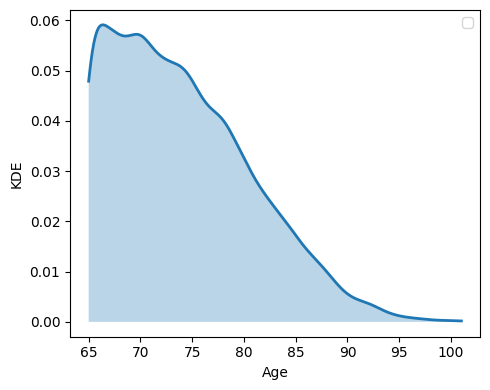

In [33]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

original_ages = data['Age'].astype(float).dropna()

# Estimación de densidad
kde_orig = gaussian_kde(original_ages)

# Rango común para comparar
x_vals = np.linspace(
  min(original_ages.min(), original_ages.min()),
  max(original_ages.max(), original_ages.max()),
  300
)

# Gráfico
plt.figure(figsize=(5, 4))
plt.plot(x_vals, kde_orig(x_vals), linewidth=2)
plt.fill_between(x_vals, kde_orig(x_vals), alpha=0.3)
plt.xlabel('Age')
plt.ylabel('KDE')

plt.legend()

plt.tight_layout()
plt.show()


===== Family_dementia_any =====
count    11461.000000
mean         0.098857
std          0.298483
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Family_dementia_any, dtype: float64
Missing values: 0
Unique values (2): [0, 1]


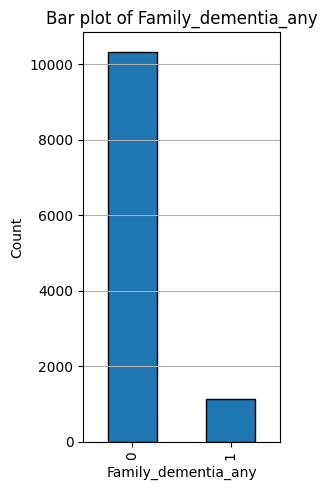


===== Sex_1F_2M =====
count    11461.000000
mean         1.360733
std          0.480213
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: Sex_1F_2M, dtype: float64
Missing values: 0
Unique values (3): [1.0, 1.3607329842931937, 2.0]


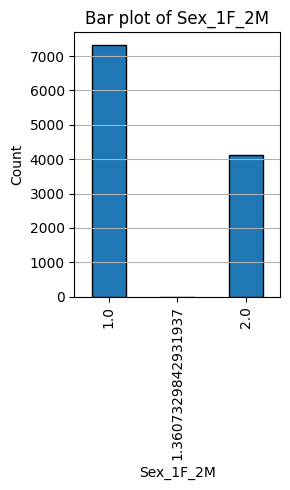


===== Education =====
count    11461.000000
mean         1.979026
std          1.163620
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: Education, dtype: float64
Missing values: 0
Unique values (6): [0.0, 1.0, 1.979026479070174, 2.0, 3.0, 4.0]


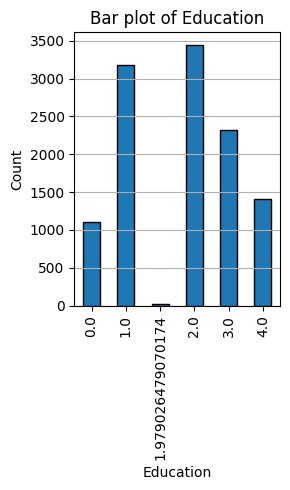


===== Disability =====
count    11461.000000
mean        10.399223
std         15.257871
min          0.000000
25%          0.000000
50%          2.777778
75%         13.888889
max        100.000000
Name: Disability, dtype: float64
Missing values: 0


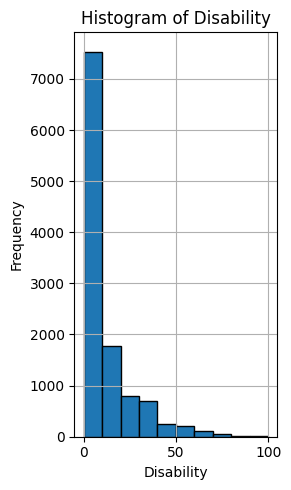


===== Assets =====
count    11461.000000
mean         5.732455
std          1.298643
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max          7.000000
Name: Assets, dtype: float64
Missing values: 0
Unique values (9): [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 5.732454608938547, 6.0, 7.0]


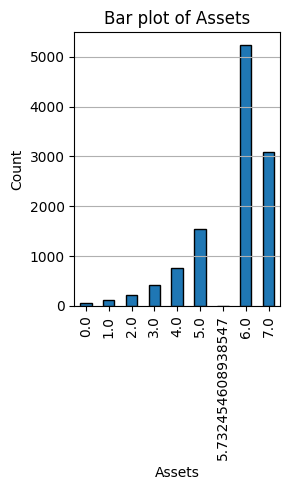


===== Ataxia =====
count    11461.000000
mean         0.147820
std          0.378123
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: Ataxia, dtype: float64
Missing values: 0
Unique values (4): [0.0, 0.14781952048329242, 1.0, 2.0]


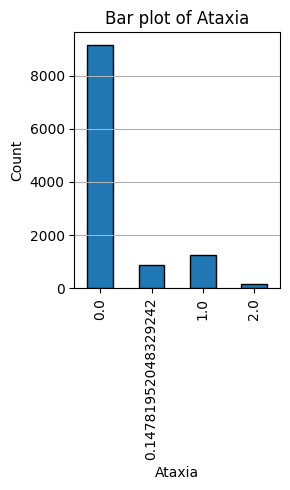


===== Bradykinesia =====
count    11461.000000
mean         0.187624
std          0.432112
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: Bradykinesia, dtype: float64
Missing values: 0
Unique values (4): [0.0, 0.1876238090746156, 1.0, 2.0]


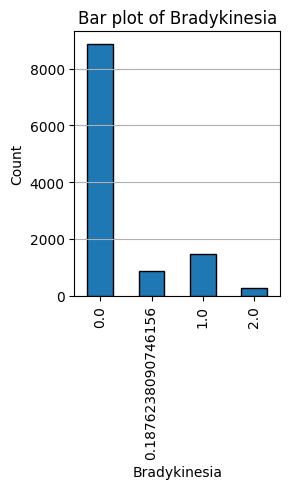


===== Hypertension_1Y_0N =====
count    11461.000000
mean         0.562718
std          0.495791
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Hypertension_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [0.0, 0.5627183787561146, 1.0]


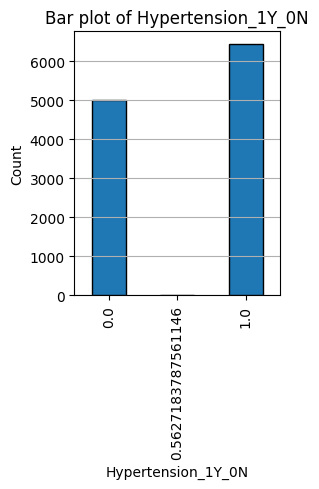


===== Heart_Disease_1Y_0N =====
count    11461.000000
mean         0.209901
std          0.407114
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Heart_Disease_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [0.0, 0.20990133589452545, 1.0]


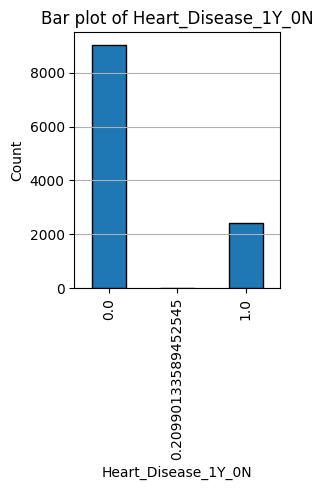


===== Vision_problems =====
count    11461.000000
mean         1.179785
std          0.886293
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Vision_problems, dtype: float64
Missing values: 0
Unique values (5): [0.0, 1.0, 1.1797850965318424, 2.0, 3.0]


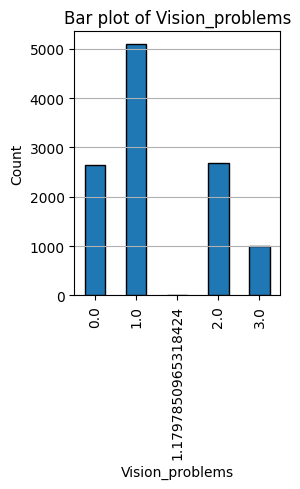


===== Audition_problems =====
count    11461.000000
mean         0.455292
std          0.808771
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: Audition_problems, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.455291652113168, 1.0, 2.0, 3.0]


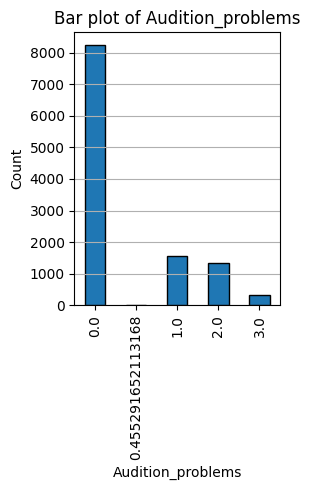


===== Cogscore =====
count    11461.000000
mean        30.242877
std          2.395257
min          0.000000
25%         29.293000
50%         30.743000
75%         31.782000
max         33.762000
Name: Cogscore, dtype: float64
Missing values: 0


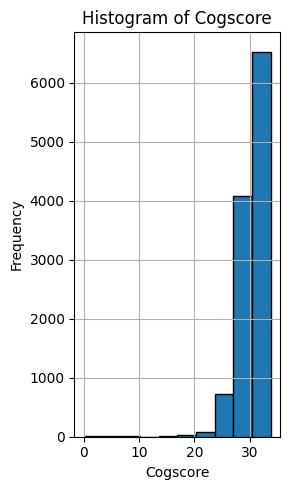


===== CERADimed =====
count    11461.000000
mean        14.463049
std          4.166177
min          0.000000
25%         12.000000
50%         14.000000
75%         17.000000
max         30.000000
Name: CERADimed, dtype: float64
Missing values: 0


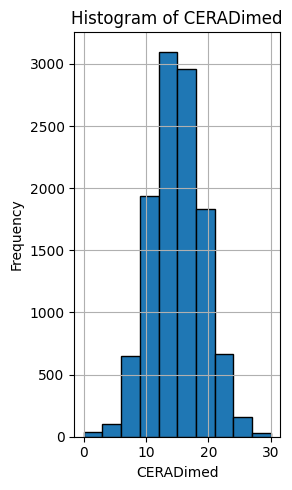


===== CERADrecall =====
count    11461.000000
mean         4.681180
std          1.995258
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: CERADrecall, dtype: float64
Missing values: 0


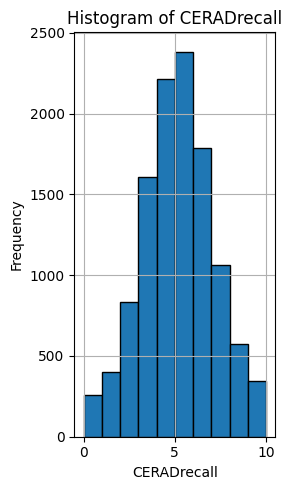


===== DSMIV =====
count    11461.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: DSMIV, dtype: float64
Missing values: 0
Unique values (1): [0]


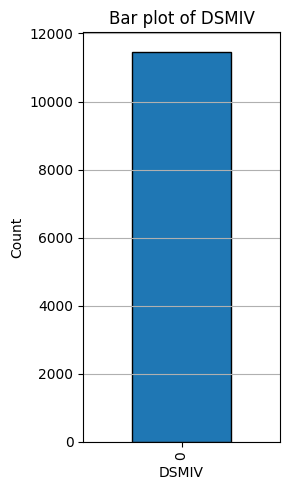


===== ICD10 =====
count    11461.000000
mean         0.053224
std          0.224490
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: ICD10, dtype: float64
Missing values: 0
Unique values (2): [0, 1]


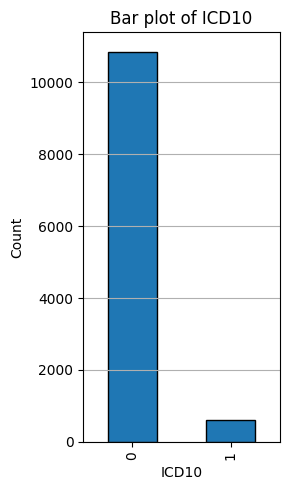


===== Euro-D =====
count    11461.000000
mean         0.259418
std          0.437952
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Euro-D, dtype: float64
Missing values: 0
Unique values (3): [0.0, 0.2594178830521808, 1.0]


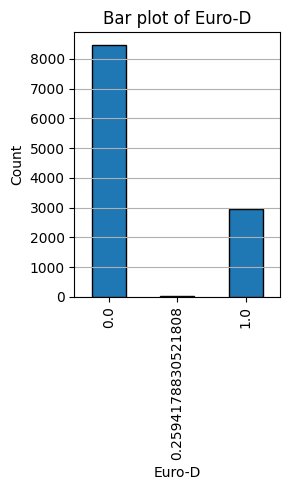


===== pulse_pressure =====
count    11461.000000
mean        56.888625
std         16.886373
min        -51.666667
25%         45.666667
50%         56.666667
75%         65.333333
max        158.666667
Name: pulse_pressure, dtype: float64
Missing values: 0


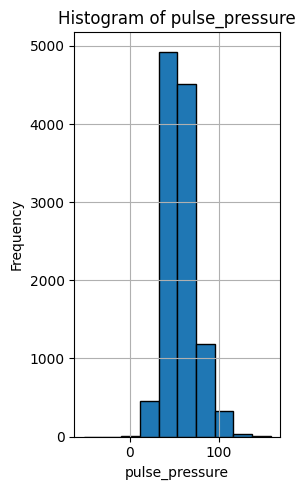


===== orthostatic_drop =====
count    11461.000000
mean         1.012518
std          0.052806
min          0.708333
25%          1.000000
50%          1.000000
75%          1.031646
max          1.955556
Name: orthostatic_drop, dtype: float64
Missing values: 0


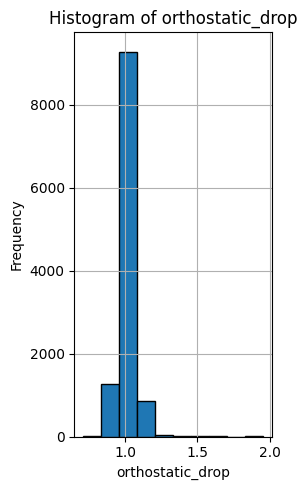


===== Stroke_1Y_0N =====
count    11461.000000
mean         0.064412
std          0.245292
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Stroke_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [0.0, 0.06441181611606363, 1.0]


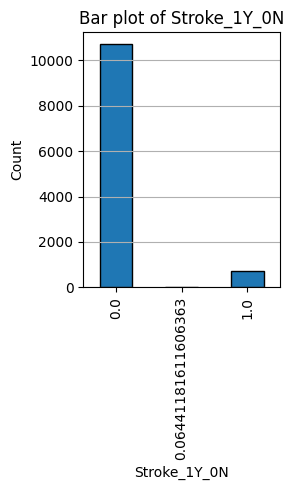


===== TIA_1Y_0N =====
count    11461.000000
mean         0.068468
std          0.251476
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: TIA_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [0.0, 0.06846783419871513, 1.0]


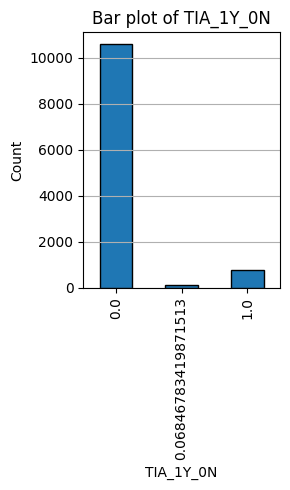


===== Back_diseases =====
count    11461.000000
mean         0.086732
std          0.198829
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.800000
Name: Back_diseases, dtype: float64
Missing values: 0
Unique values (13): [0.0, 0.08673240829624458, 0.2, 0.25, 0.3333333333333333, 0.4, 0.5, 0.6, 0.75, 0.8, 1.0, 1.4, 1.8]


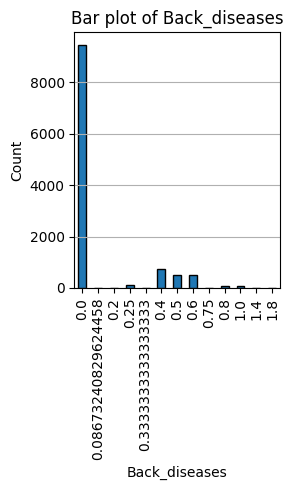


===== SRQ =====
count    11461.000000
mean         2.739351
std          3.378156
min          0.000000
25%          0.000000
50%          2.000000
75%          4.000000
max         20.000000
Name: SRQ, dtype: float64
Missing values: 0


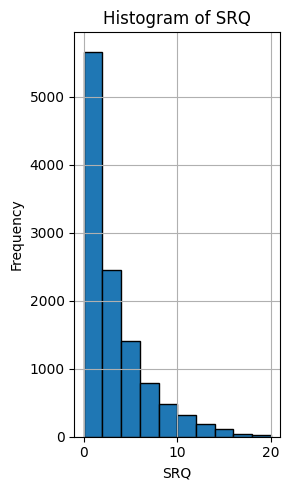


===== NPI distress score =====
count    11461.000000
mean         2.484865
std          4.349452
min          0.000000
25%          0.000000
50%          0.000000
75%          3.000000
max         50.000000
Name: NPI distress score, dtype: float64
Missing values: 0


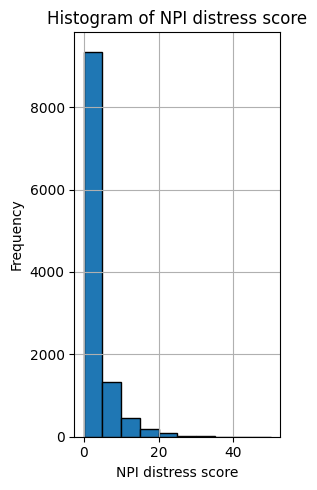


===== NPI severity score =====
count    11461.000000
mean         2.435984
std          3.437906
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         26.000000
Name: NPI severity score, dtype: float64
Missing values: 0


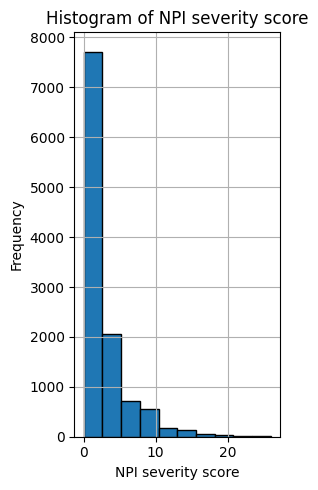


===== Arthritis =====
count    11461.000000
mean         0.776400
std          1.024038
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max          3.000000
Name: Arthritis, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.7763996855620579, 1.0, 2.0, 3.0]


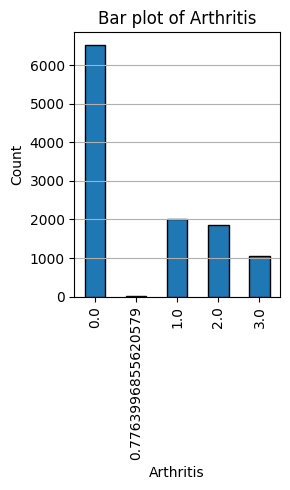


===== Cough =====
count    11461.000000
mean         0.187074
std          0.560423
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Cough, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.18707423580786026, 1.0, 2.0, 3.0]


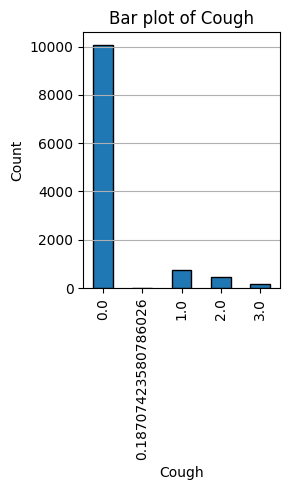


===== Breathlessness =====
count    11461.000000
mean         0.247140
std          0.643981
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Breathlessness, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.24713998777399354, 1.0, 2.0, 3.0]


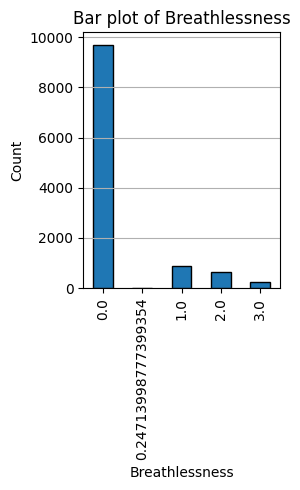


===== Breath_problems =====
count    11461.000000
mean         0.217148
std          0.486731
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Breath_problems, dtype: float64
Missing values: 0
Unique values (8): [0.0, 0.21714834541168254, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]


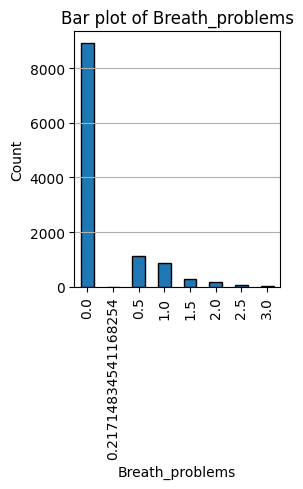


===== Angina =====
count    11461.000000
mean         0.248516
std          0.588778
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Angina, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.24851554313657004, 1.0, 2.0, 3.0]


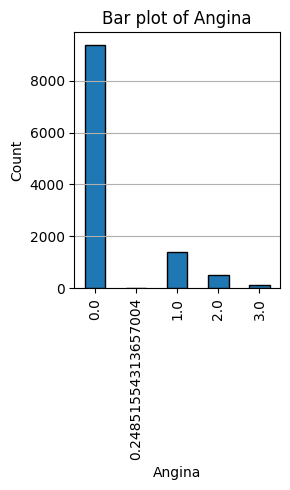


===== Stomach_problems =====
count    11461.000000
mean         0.500480
std          0.839718
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: Stomach_problems, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.5004803073967339, 1.0, 2.0, 3.0]


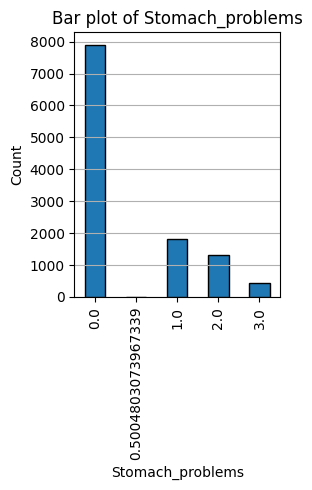


===== Faints =====
count    11461.000000
mean         0.057472
std          0.322266
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Faints, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.05747226832037733, 1.0, 2.0, 3.0]


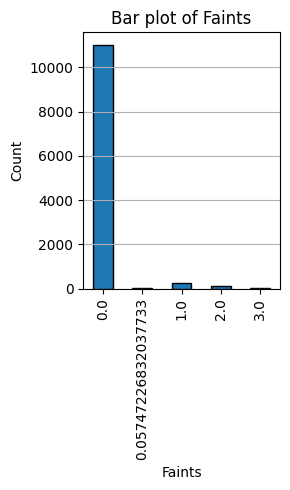


===== Paralysis =====
count    11461.000000
mean         0.120077
std          0.506321
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Paralysis, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.12007684918347743, 1.0, 2.0, 3.0]


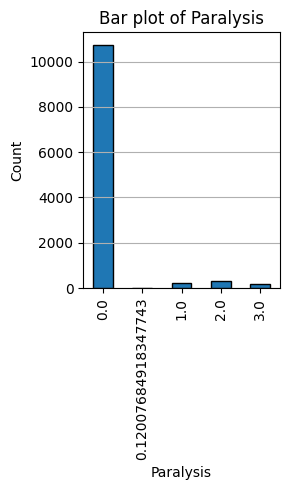


===== Limiting_illnesses =====
count    11461.000000
mean         0.762586
std          0.719644
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: Limiting_illnesses, dtype: float64
Missing values: 0
Unique values (3): [0.0, 1.0, 2.0]


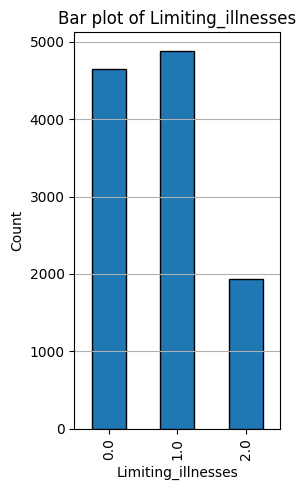


===== Skin_disorder =====
count    11461.000000
mean         0.103048
std          0.424429
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Skin_disorder, dtype: float64
Missing values: 0
Unique values (5): [0.0, 0.10304776875382063, 1.0, 2.0, 3.0]


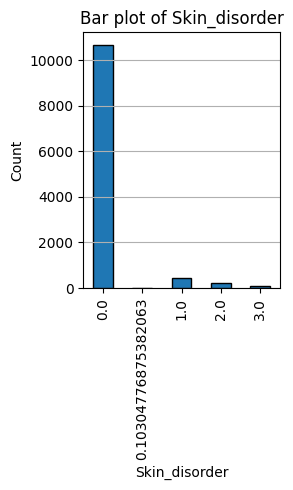


===== Pain =====
count    11461.000000
mean         1.357868
std          1.299435
min          0.333333
25%          0.333333
50%          0.333333
75%          2.333333
max          5.000000
Name: Pain, dtype: float64
Missing values: 0


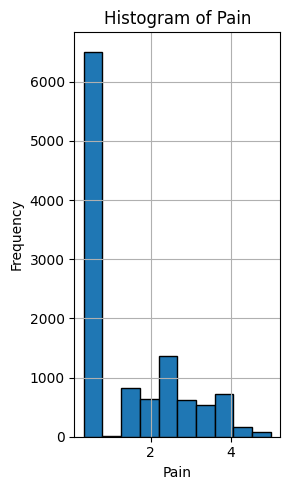


===== Emotional_Disability =====
count    11461.000000
mean         0.230862
std          0.437966
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          4.000000
Name: Emotional_Disability, dtype: float64
Missing values: 0


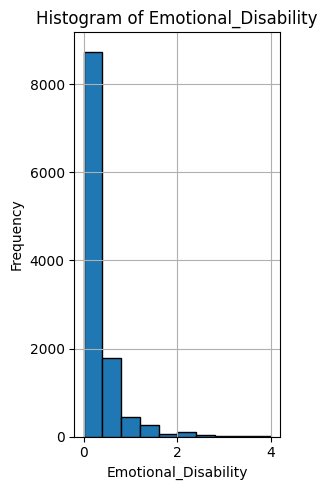


===== Physical_activities =====
count    11461.000000
mean         1.904090
std          0.840094
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: Physical_activities, dtype: float64
Missing values: 0
Unique values (5): [0.0, 1.0, 1.9040903915214153, 2.0, 3.0]


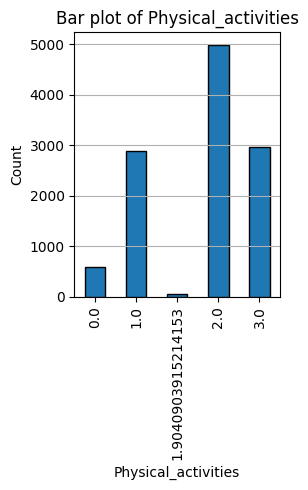


===== Walk_1Y_0N =====
count    11461.000000
mean         0.616592
std          0.485006
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Walk_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [0.0, 0.6165921248794177, 1.0]


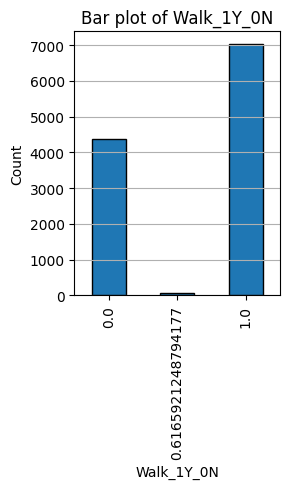


===== Exercise_increase =====
count    11461.000000
mean         1.350544
std          0.605863
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Exercise_increase, dtype: float64
Missing values: 0
Unique values (4): [1.0, 1.3505444327362135, 2.0, 3.0]


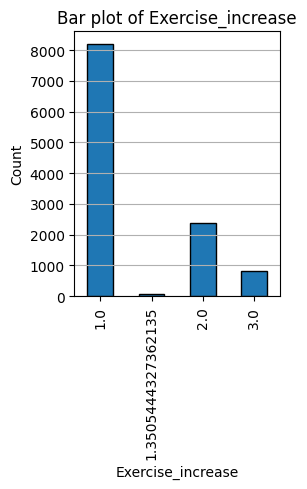


===== Medic_visits =====
count    11461.000000
mean         0.088016
std          0.144119
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          0.750000
Name: Medic_visits, dtype: float64
Missing values: 0
Unique values (4): [0.0, 0.25, 0.5, 0.75]


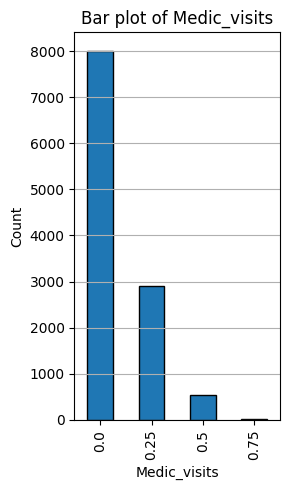


===== Medications_1Y_0N =====
count    11461.000000
mean         0.739377
std          0.438994
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Medications_1Y_0N, dtype: float64
Missing values: 0
Unique values (2): [0.0, 1.0]


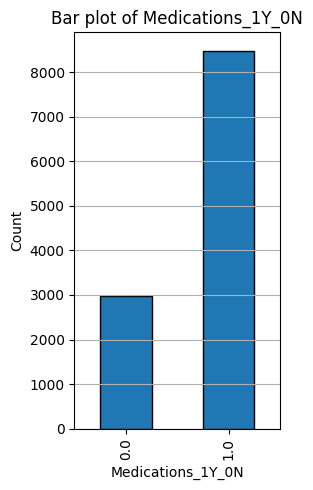

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Lista de variables a analizar


# Análisis descriptivo
for var in vars_list:
  print(f"\n===== {var} =====")
  print(data[var].describe())
  print("Missing values:", data[var].isna().sum())
  
  # Obtener valores únicos
  unique_vals = data[var].dropna().unique()
  n_unique = len(unique_vals)
  
  if n_unique < 15:
    print(f"Unique values ({n_unique}): {sorted(unique_vals)}")
    
    # Gráfico de barras para variables categóricas
    value_counts = data[var].value_counts().sort_index()
    plt.figure(figsize=(3,5))
    value_counts.plot(kind='bar', edgecolor='black')
    plt.title(f'Bar plot of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
  else:
    # Histograma para variables continuas
    plt.figure(figsize=(3,5))
    plt.hist(data[var].dropna(), bins=10, edgecolor='black')
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [35]:
vars_list

['Family_dementia_any',
 'Sex_1F_2M',
 'Education',
 'Disability',
 'Assets',
 'Ataxia',
 'Bradykinesia',
 'Hypertension_1Y_0N',
 'Heart_Disease_1Y_0N',
 'Vision_problems',
 'Audition_problems',
 'Cogscore',
 'CERADimed',
 'CERADrecall',
 'DSMIV',
 'ICD10',
 'Euro-D',
 'pulse_pressure',
 'orthostatic_drop',
 'Stroke_1Y_0N',
 'TIA_1Y_0N',
 'Back_diseases',
 'SRQ',
 'NPI distress score',
 'NPI severity score',
 'Arthritis',
 'Cough',
 'Breathlessness',
 'Breath_problems',
 'Angina',
 'Stomach_problems',
 'Faints',
 'Paralysis',
 'Limiting_illnesses',
 'Skin_disorder',
 'Pain',
 'Emotional_Disability',
 'Physical_activities',
 'Walk_1Y_0N',
 'Exercise_increase',
 'Medic_visits',
 'Medications_1Y_0N']

In [36]:
import pandas as pd

mi_lista = ['Family_dementia_any',
 'Sex_1F_2M',
 'Education',
 'Disability',
 'Assets',
 'Ataxia',
 'Bradykinesia',
 'Hypertension_1Y_0N',
 'Heart_Disease_1Y_0N',
 'Vision_problems',
 'Audition_problems',
 'Cogscore',
 'CERADimed',
 'CERADrecall',
 'DSMIV',
 'ICD10',
 'Euro-D',
 'pulse_pressure',
 'orthostatic_drop',
 'Stroke_1Y_0N',
 'TIA_1Y_0N',
 'Back_diseases',
 'SRQ',
 'NPI distress score',
 'NPI severity score',
 'Arthritis',
 'Cough',
 'Breathlessness',
 'Breath_problems',
 'Angina',
 'Stomach_problems',
 'Faints',
 'Paralysis',
 'Limiting_illnesses',
 'Skin_disorder',
 'Pain',
 'Emotional_Disability',
 'Physical_activities',
 'Walk_1Y_0N',
 'Exercise_increase',
 'Medic_visits',
 'Medications_1Y_0N']

#df = pd.DataFrame(mi_lista, columns=['valores'])

#df.to_excel('variables_descripcion_template.xlsx', index=False)

['Family_dementia_any', X
 'Sex_1F_2M', X
 'Education', X
 'Disability', X
 'Assets', X
 'Ataxia', X
 'Bradykinesia', X
 'Hypertension_1Y_0N', X
 'Heart_Disease_1Y_0N', X
 'Vision_problems', X
 'Audition_problems', X
 'Cogscore', X
 'CERADimed', X
 'CERADrecall', X
 'DSMIV', X
 'ICD10', X
 'Euro-D', X
 'pulse_pressure', X
 'orthostatic_drop',
 'Stroke_1Y_0N', X
 'TIA_1Y_0N', X
 'Back_diseases', X infectious 
 'SRQ', X
 'NPI distress score', X
 'NPI severity score', X
 'Arthritis', X
 'Cough', X
 'Breathlessness',X
 'Breath_problems', X
 'Angina', X
 'Stomach_problems', X
 'Faints', X
 'Paralysis', X
 'Limiting_illnesses', X
 'Skin_disorder', X
 'Pain', X
 'Emotional_Disability', X
 'Physical_activities', X
 'Walk_1Y_0N', X
 'Exercise_increase', X
 'Medic_visits', X
 'Medications_1Y_0N' X]

In [37]:
data[vars_list].describe()

,Family_dementia_any,Sex_1F_2M,Education,Disability,Assets,Ataxia,Bradykinesia,Hypertension_1Y_0N,Heart_Disease_1Y_0N,Vision_problems,...,Paralysis,Limiting_illnesses,Skin_disorder,Pain,Emotional_Disability,Physical_activities,Walk_1Y_0N,Exercise_increase,Medic_visits,Medications_1Y_0N
count,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,...,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000,11461.000000
mean,0.098857,1.360733,1.979026,10.399223,5.732455,0.147820,0.187624,0.562718,0.209901,1.179785,...,0.120077,0.762586,0.103048,1.357868,0.230862,1.904090,0.616592,1.350544,0.088016,0.739377
std,0.298483,0.480213,1.163620,15.257871,1.298643,0.378123,0.432112,0.495791,0.407114,0.886293,...,0.506321,0.719644,0.424429,1.299435,0.437966,0.840094,0.485006,0.605863,0.144119,0.438994
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.333333,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,2.000000,2.777778,6.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.333333,0.000000,2.000000,1.000000,1.000000,0.000000,1.000000
75%,0.000000,2.000000,3.000000,13.888889,7.000000,0.000000,0.000000,1.000000,0.000000,2.000000,...,0.000000,1.000000,0.000000,2.333333,0.250000,3.000000,1.000000,2.000000,0.250000,1.000000
max,1.000000,2.000000,4.000000,100.000000,7.000000,2.000000,2.000000,1.000000,1.000000,3.000000,...,3.000000,2.000000,3.000000,5.000000,4.000000,3.000000,1.000000,3.000000,0.750000,1.000000


### SFS all subjects

In [38]:
best_features = get_best_features_sfs(data, vars_list,
                   target_col="Age",
                   pkl_path="SFS/best_features-all-vars_all-subjects_onlyCN.pkl",
                   force=False)


Loaded best_features from pickle: ['Family_dementia_any', 'Sex_1F_2M', 'Disability', 'Assets', 'Ataxia', 'Bradykinesia', 'Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Vision_problems', 'Audition_problems', 'Cogscore', 'CERADrecall', 'DSMIV', 'ICD10', 'Euro-D', 'pulse_pressure', 'Stroke_1Y_0N', 'TIA_1Y_0N', 'Back_diseases', 'NPI distress score', 'NPI severity score', 'Arthritis', 'Cough', 'Breath_problems', 'Paralysis', 'Limiting_illnesses', 'Pain', 'Emotional_Disability', 'Physical_activities', 'Walk_1Y_0N', 'Exercise_increase', 'Medications_1Y_0N']


In [39]:
## Asegurar que estas se tienen en cuenta
best_features.append('Sex_1F_2M')
best_features.append('Education')

best_features = list(np.unique(best_features))

### BBAGs model-all subjects

In [40]:
#!pip install scikit-optimize

#from scipy.stats import pointbiserialr
#
## Suponiendo que 'Age' es continua y 'Grupo' es binaria 0/1
#corr, p_value = pointbiserialr(data['Diabetes_1Y_0N'], data['Age'])
#
#print(f"Correlación punto-biserial: {corr:.3f}, p-valor: {p_value:.3f}")
#

In [41]:
r2_scores, r2_adj_scores, results_df, shap_imp, perm_imp, r2_global, r2_adj_global = run_nested_cv_hgbr(
  data_=data,
  best_features=best_features,
  y_col="Age",
  diag_col="anydem"
)


🔁 Fold 1 (Nested CV)
🏆 R² fold 1: 0.2598 | R² adj: 0.2378 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 2 (Nested CV)
🏆 R² fold 2: 0.2048 | R² adj: 0.1812 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400})
🔁 Fold 3 (Nested CV)
🏆 R² fold 3: 0.2424 | R² adj: 0.2199 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400})
🔁 Fold 4 (Nested CV)
🏆 R² fold 4: 0.2481 | R² adj: 0.2258 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 5 (Nested CV)
🏆 R² fold 5: 0.2334 | R² adj: 0.2107 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400})
🔁 Fold 6 (Nested CV)
🏆 R² fold 6: 0.2589 | R² adj: 0.2369 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 7 (Nested CV)
🏆

In [42]:
data

,Countries,smoke_years,smoke_ratio,Family_dementia_n,Family_dementia_any,Sex_1F_2M,Education,Disability,Assets,Ataxia,...,mci,eurocase,anydem,cogcase,prfrate,date,particid,householdid,centreid,pulse_pressure
0,Cuba,32.0,0.415584,2.0,1,2.0,3.0,2.777778,6.0,0.00000,...,0,1.0,0.0,1,0.0,2003-10-07,2,1,1,66.333333
1,Cuba,23.0,0.353846,1.0,1,1.0,4.0,22.222222,7.0,0.00000,...,0,1.0,0.0,1,0.0,2003-09-01,1,2,1,47.666667
2,Cuba,0.0,0.000000,NaN,0,1.0,3.0,8.333333,6.0,0.00000,...,0,1.0,0.0,1,0.0,2003-09-02,1,3,1,130.000000
3,Cuba,0.0,0.000000,NaN,0,1.0,3.0,0.000000,6.0,0.00000,...,0,0.0,0.0,1,0.0,2003-10-07,1,4,1,41.666667
4,Cuba,0.0,0.000000,NaN,0,1.0,2.0,22.222222,6.0,0.00000,...,0,0.0,0.0,1,0.0,2003-09-25,1,5,1,49.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11456,Puerto Rico,0.0,0.000000,NaN,0,1.0,1.0,0.000000,6.0,0.14782,...,0,0.0,0.0,2,0.0,2009-06-23,1,10264,20,56.888625
11457,Puerto Rico,0.0,0.000000,NaN,0,1.0,3.0,25.000000,6.0,1.00000,...,0,0.0,0.0,1,0.0,2009-06-23,1,10265,20,50.000000
11458,Puerto Rico,0.0,0.000000,1.0,1,1.0,3.0,27.777778,7.0,1.00000,...,0,0.0,0.0,1,0.0,2009-06-23,1,10266,20,50.666667
11459,Puerto Rico,0.0,0.000000,1.0,1,1.0,4.0,0.000000,7.0,0.00000,...,0,0.0,0.0,1,0.0,2009-06-23,2,10266,20,47.333333


In [43]:
def make_generic_id(row):
  h = row['householdid']
  p = row['particid']
  def to_str(val):
    if pd.isna(val): return ""
    if isinstance(val, float) and val.is_integer(): return str(int(val))
    return str(val)
  if pd.isna(h) or pd.isna(p): return np.nan
  uid_str = to_str(h) + "_" + to_str(p)
  return 'SUBJ_' + hashlib.md5(uid_str.encode()).hexdigest()[:8]

if 'particid' in data.columns and 'householdid' in data.columns:
  data['generic_id'] = data.apply(make_generic_id, axis=1)

results_df['y_pred_corrected'] = results_df['y_labels'] + results_df['GAP_corrected']
results_df = results_df.set_index('ID')

results_df = results_df.sort_index()

df_final = pd.concat([data[['generic_id', 'date', 'Age', 'anydem', 'dsmcase', 'cogcase', 'mci', 'Countries'] + best_features], results_df], axis = 1)

In [44]:
df_final.to_parquet('Results/all-vars_all-subjects_onlyCN.parquet')

perm_imp.to_frame(name="perm_importance").to_parquet("Results/all-vars_all-subjects-perm_imp_onlyCN.parquet")


import pickle

out = {
  "r2_scores": r2_scores,
  "r2_adj_scores": r2_adj_scores,
  "r2_global": r2_global,
  "r2_adj_global": r2_adj_global
}

with open("Results/r2_all-vars_all-subjects_onlyCN.pkl", "wb") as f:
  pickle.dump(out, f)


### Filtering bad subjects

In [45]:
data_filtered, non_cn_bad_subjects, r2_scores, results_df = nested_cv_flag_bad_subjects(
  data_=data,
  best_features=best_features,
  y_col="Age",
  diag_col="anydem"
)


🔁 Fold 1 (Nested CV)
🏆 R² fold 1: 0.2577
🔁 Fold 2 (Nested CV)
🏆 R² fold 2: 0.2017
🔁 Fold 3 (Nested CV)
🏆 R² fold 3: 0.2455
🔁 Fold 4 (Nested CV)
🏆 R² fold 4: 0.2474
🔁 Fold 5 (Nested CV)
🏆 R² fold 5: 0.2340
🔁 Fold 6 (Nested CV)
🏆 R² fold 6: 0.2635
🔁 Fold 7 (Nested CV)
🏆 R² fold 7: 0.2180
🔁 Fold 8 (Nested CV)
🏆 R² fold 8: 0.2571
🔁 Fold 9 (Nested CV)
🏆 R² fold 9: 0.2649
🔁 Fold 10 (Nested CV)
🏆 R² fold 10: 0.2337
🚩 Sujetos identificados (NO CN) con impacto negativo: 0
✅ Nuevo dataframe filtrado: (11461, 86)

📊 R² promedio: 0.2423444109806042 0.01959350222639961
📊 R² global: 0.2428592208740039


### BBAGs model-filtered subjects (same results as all-subjects since no subject had a negative impact)

In [46]:
r2_scores, r2_adj_scores, results_df, shap_imp, perm_imp, r2_global, r2_adj_global = run_nested_cv_hgbr(
  data_=data_filtered,
  best_features=best_features,
  y_col="Age",
  diag_col="anydem"
)


🔁 Fold 1 (Nested CV)
🏆 R² fold 1: 0.2598 | R² adj: 0.2378 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 2 (Nested CV)
🏆 R² fold 2: 0.2048 | R² adj: 0.1812 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400})
🔁 Fold 3 (Nested CV)
🏆 R² fold 3: 0.2424 | R² adj: 0.2199 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400})
🔁 Fold 4 (Nested CV)
🏆 R² fold 4: 0.2481 | R² adj: 0.2258 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 5 (Nested CV)
🏆 R² fold 5: 0.2334 | R² adj: 0.2107 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400})
🔁 Fold 6 (Nested CV)
🏆 R² fold 6: 0.2589 | R² adj: 0.2369 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 7 (Nested CV)
🏆

In [47]:
if 'particid' in data_filtered.columns and 'householdid' in data_filtered.columns:
  data_filtered['generic_id'] = data_filtered.apply(make_generic_id, axis=1)

results_df['y_pred_corrected'] = results_df['y_labels'] + results_df['GAP_corrected']
results_df = results_df.set_index('ID')

results_df = results_df.sort_index()

df_final = pd.concat([data_filtered[['generic_id', 'date', 'Age', 'anydem', 'dsmcase', 'cogcase', 'mci', 'Countries'] + best_features], results_df], axis = 1)

In [48]:
df_final.to_parquet('Results/all-vars_filtered-subjects_onlyCN.parquet')
perm_imp.to_frame(name="perm_importance").to_parquet("Results/all-vars_filtered-subjects-perm_imp_onlyCN.parquet")


out = {
  "r2_scores": r2_scores,
  "r2_adj_scores": r2_adj_scores,
  "r2_global": r2_global,
  "r2_adj_global": r2_adj_global
}

with open("Results/r2_all-vars_filtered-subjects_onlyCN.pkl", "wb") as f:
  pickle.dump(out, f)
